<a href="https://colab.research.google.com/github/ktw-98/Portfolio/blob/main/Robust_Trajectory_Planning.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Robust Trajectory Planning

## 0. Nominal Trajectory 생성
- Optimal Trajectory Planning에서 QP용 코드만 갖고옴

In [ ]:
#!pip install ECOS
!pip install ecos scs
import numpy as np
import matplotlib.pyplot as plt
import scipy.sparse as sp
import scipy.sparse.linalg as sla

import jax
import jax.numpy as jnp
from tqdm import tqdm
import cvxpy as cp

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 222.1/222.1 kB 3.8 MB/s eta 0:00:00


In [ ]:
N = 300
T = 30
ts = np.linspace(0, T, N+1)
h = T / N

gamma = 0.05
g = 9.8

n = 6   # state dim
m = 3   # control dim

x0 = np.array([1000, 500, 5000, 50, -10, -300])

In [ ]:
I3 = np.eye(3)

A = np.block([
    [I3, (1 - gamma*h/2)*h*I3],
    [np.zeros((3,3)), (1 - gamma*h)*I3]
])

B = np.block([
    [(h**2)/2 * I3],
    [h * I3]
])

b = np.array([0, 0, -0.5*g*h**2, 0, 0, -g*h])

# Q_list = []
# for t in range(N):
#     alpha = np.exp(-(N - t)/18)       # 후반으로 갈 수록 커짐
#     Q_list.append(alpha * np.diag([1, 1, 0, 10, 10, 0]))
# Q_N = np.diag([10, 10, 100, 100, 100, 1000])

# R = np.eye(3)

Q = []
R = []
Q_tilde = []
R_tilde = []
for t in range(N):
  Qt = np.exp(-(N-t)/15)*np.diag([10,10,  0,100,100,   0])
  Rt = np.eye(m)
  Q.append(Qt)
  R.append(Rt)
Q.append(np.diag([ 10,10,100,100,100,1000]))


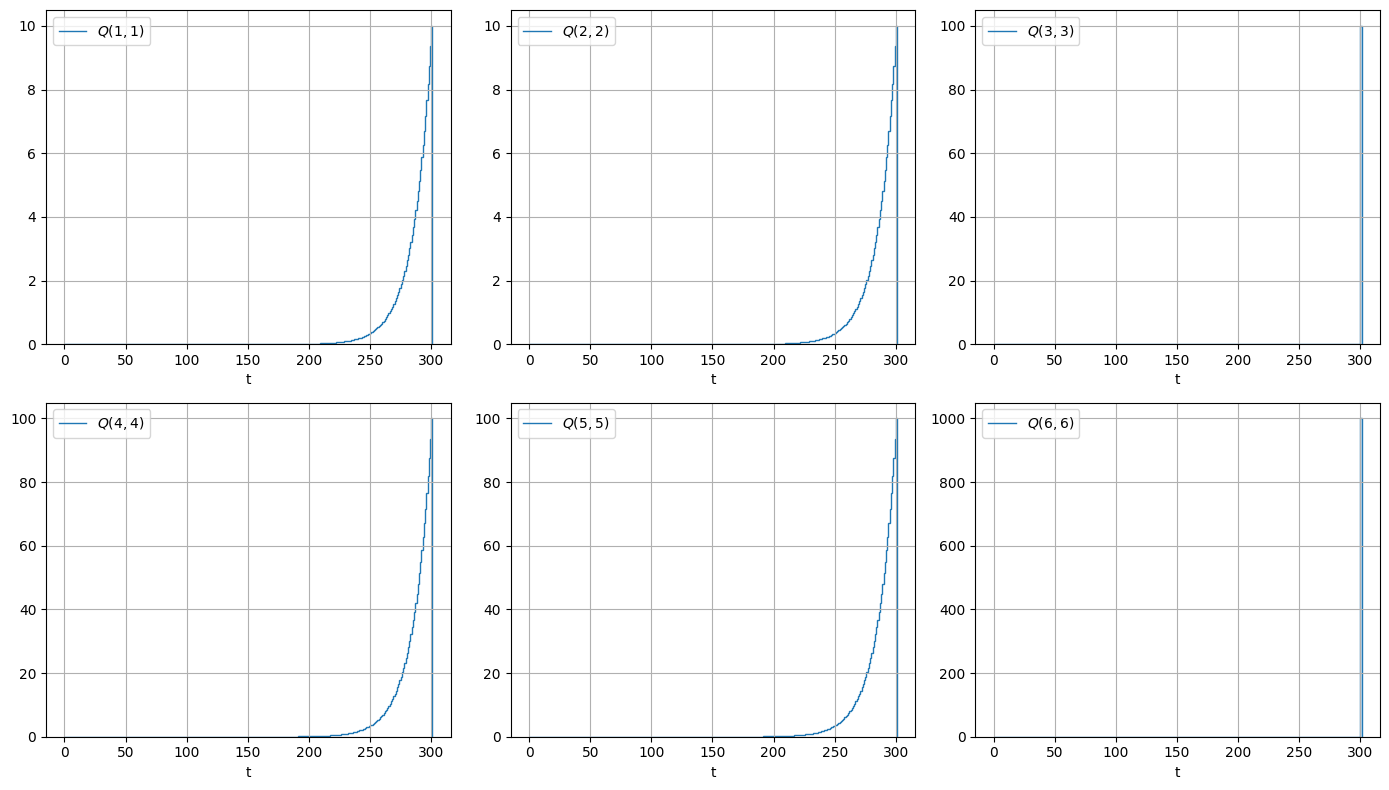

In [ ]:
labels_x = [r'$p_e$', r'$p_n$', r'$p_u$', r'$v_e$', r'$v_n$', r'$v_u$']

plt.figure(figsize=(14,8), dpi=100)
for i in range(6):
    plt.subplot(2,3,i+1)
    plt.stairs([Q[t][i,i] for t in range(N+1)],
               label=rf'$Q({i+1},{i+1})$')
    plt.grid(); plt.legend(); plt.xlabel('t')
plt.tight_layout()
plt.show()


In [ ]:
u_min = np.array([-10, -10, 0])
u_max = np.array([ 10,  10, 20])
RADIUS = 30.0     # 30m 원 (소프트)
w_rad  = 1e4      # 원 밖 위반 페널티
w_xy   = 1e3      # 원 안에서도 원점으로 더 끌기(원하면 0으로)

w_du = 100.0      # 입력 스무딩(원하면 0으로)

# 목표 중심(원점 기준이면 0)
x_des = np.zeros(6)

# ===== decision variables =====
X = cp.Variable((6, N+1))
U = cp.Variable((3, N))

constraints = [X[:, 0] == x0]

# ===== hard dynamics =====
for t in range(N):
    constraints += [X[:, t+1] == A @ X[:, t] + B @ U[:, t] + b]

# ===== hard input box constraints =====
constraints += [U >= u_min[:, None], U <= u_max[:, None]]

# ===== hard ground constraint =====
constraints += [X[2, :] >= 0.0]        # p_u(t) >= 0

# ===== hard terminal constraints =====
constraints += [X[2, N] == 0.0]        # p_u(N)=0
constraints += [X[3:6, N] == 0.0]      # v(N)=0

# =========================
# cost
# =========================
cost = 0

# running state/input quadratic cost
for t in range(N):
    cost += cp.quad_form(X[:, t], Q[t])
    cost += cp.quad_form(U[:, t], R[t])

# terminal cost
cost += cp.quad_form(X[:, N], Q[N])

# input smoothing (optional)
for t in range(N-1):
    cost += w_du * cp.sum_squares(U[:, t+1] - U[:, t])

# soft circle penalty (terminal only)
peN = X[0, N] - x_des[0]
pnN = X[1, N] - x_des[1]
rad_violation = cp.pos(cp.norm(cp.hstack([peN, pnN]), 2) - RADIUS)
cost += w_rad * cp.square(rad_violation)

# (optional) pull-to-center even inside circle
cost += w_xy * (peN**2 + pnN**2)

problem = cp.Problem(cp.Minimize(cost), constraints)
problem.solve(solver=cp.CLARABEL, verbose=True)

X_opt = X.value
U_opt = U.value

print("status:", problem.status)
print("U_opt min/max per axis:", U_opt.min(axis=1), U_opt.max(axis=1))
print("terminal position:", X_opt[:3, -1])
print("terminal velocity:", X_opt[3:6, -1])
print("terminal radius:", np.linalg.norm(X_opt[0:2, -1] - x_des[0:2]))
print("min p_u:", np.min(X_opt[2, :]))

(CVXPY) Mar 09 07:12:21 PM: Your problem has 2706 variables, 3911 constraints, and 0 parameters.


                                     CVXPY                                     
                                     v1.6.7                                    


(CVXPY) Mar 09 07:12:21 PM: It is compliant with the following grammars: DCP, DQCP
(CVXPY) Mar 09 07:12:21 PM: (If you need to solve this problem multiple times, but with different data, consider using parameters.)
(CVXPY) Mar 09 07:12:21 PM: CVXPY will first compile your problem; then, it will invoke a numerical solver to obtain a solution.
(CVXPY) Mar 09 07:12:21 PM: Your problem is compiled with the CPP canonicalization backend.
(CVXPY) Mar 09 07:12:21 PM: Compiling problem (target solver=CLARABEL).
(CVXPY) Mar 09 07:12:21 PM: Reduction chain: Dcp2Cone -> CvxAttr2Constr -> ConeMatrixStuffing -> CLARABEL
(CVXPY) Mar 09 07:12:21 PM: Applying reduction Dcp2Cone


-------------------------------------------------------------------------------
                                  Compilation                                  
-------------------------------------------------------------------------------


(CVXPY) Mar 09 07:12:22 PM: Applying reduction CvxAttr2Constr
(CVXPY) Mar 09 07:12:22 PM: Applying reduction ConeMatrixStuffing
(CVXPY) Mar 09 07:12:24 PM: Applying reduction CLARABEL
(CVXPY) Mar 09 07:12:24 PM: Finished problem compilation (took 3.150e+00 seconds).
(CVXPY) Mar 09 07:12:24 PM: Invoking solver CLARABEL  to obtain a solution.


-------------------------------------------------------------------------------
                                Numerical solver                               
-------------------------------------------------------------------------------
-------------------------------------------------------------
           Clarabel.rs v0.11.1  -  Clever Acronym                

                   (c) Paul Goulart                          
                University of Oxford, 2022                   
-------------------------------------------------------------

problem:
  variables     = 6314
  constraints   = 7522
  nnz(P)        = 3006
  nnz(A)        = 16526
  cones (total) = 3
    :        Zero = 1,  numel = 5416
    : Nonnegative = 1,  numel = 2103
    : SecondOrder = 1,  numel = 3

settings:
  linear algebra: direct / qdldl, precision: 64 bit (1 thread)
  max iter = 200, time limit = Inf,  max step = 0.990
  tol_feas = 1.0e-8, tol_gap_abs = 1.0e-8, tol_gap_rel = 1.0e-8,
  static reg : on, ϵ1

(CVXPY) Mar 09 07:12:25 PM: Problem status: optimal
(CVXPY) Mar 09 07:12:25 PM: Optimal value: 1.737e+05
(CVXPY) Mar 09 07:12:25 PM: Compilation took 3.150e+00 seconds
(CVXPY) Mar 09 07:12:25 PM: Solver (including time spent in interface) took 2.315e-01 seconds


-------------------------------------------------------------------------------
                                    Summary                                    
-------------------------------------------------------------------------------
status: optimal
U_opt min/max per axis: [-10.          -5.58389491   2.12816824] [10.          3.01313569 19.99999996]
terminal position: [ 3.61887834e-02 -4.66533889e-04  1.49252599e-12]
terminal velocity: [ 3.56270837e-15 -3.12812535e-20  1.73785505e-15]
terminal radius: 0.03619179049308618
min p_u: 1.4925259921382899e-12


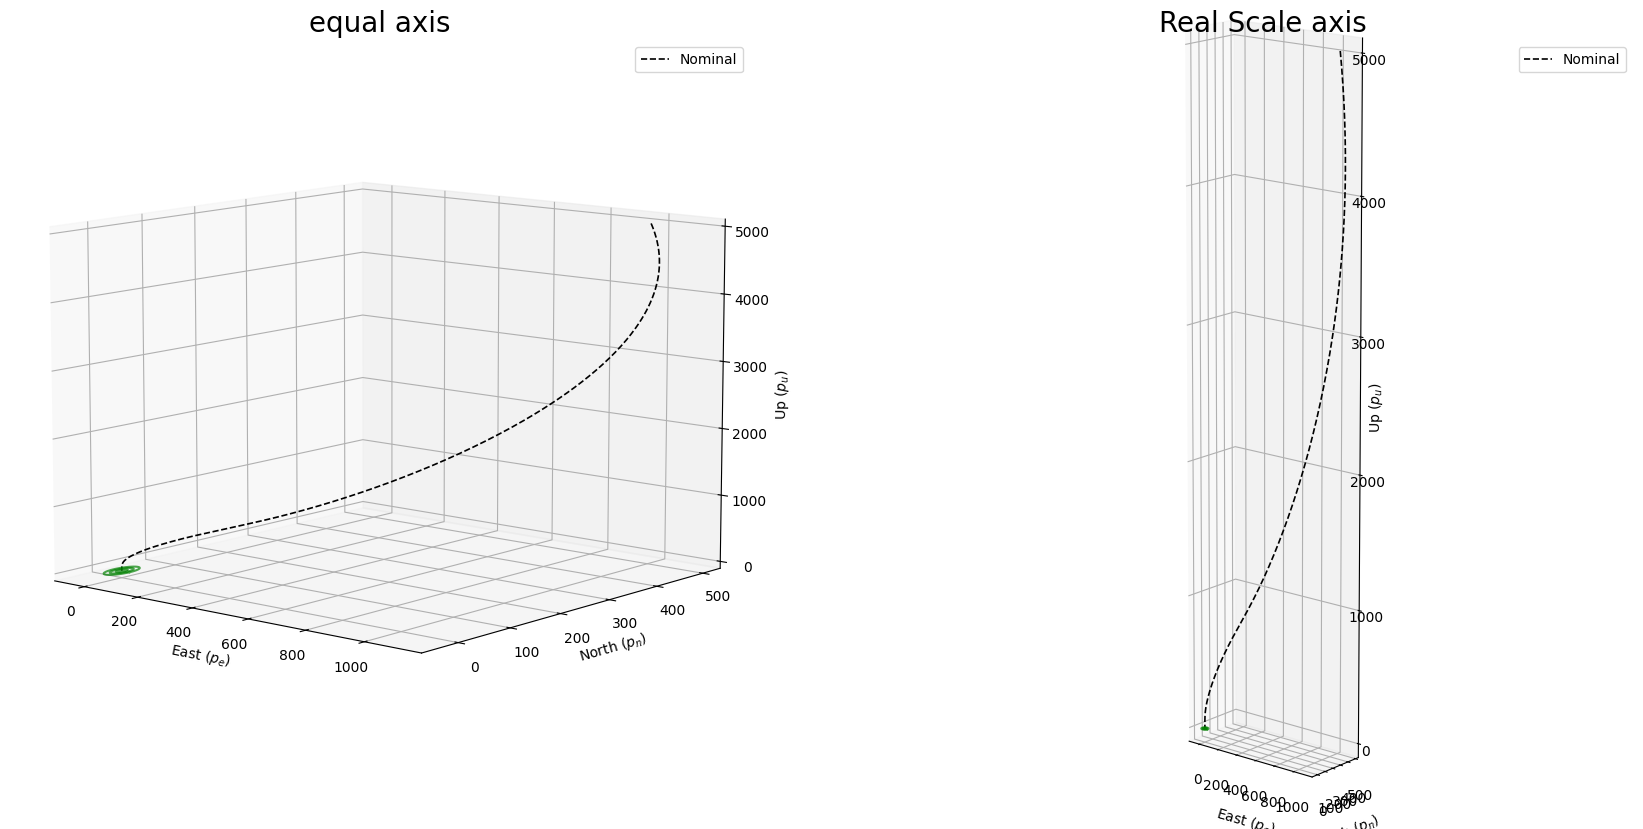

In [ ]:
import matplotlib.pyplot as plt
import numpy as np

fig = plt.figure(figsize=(18, 8), dpi=100)

theta = np.linspace(0, 2*np.pi, 200)
radii = [10, 20, 30]

# =========================
# Left subplot
# =========================
ax1 = fig.add_subplot(1, 2, 1, projection='3d')
ax1.view_init(elev=10, azim=-50, roll=0)

# OPT trajectory
ax1.plot(X_opt[0, :], X_opt[1, :], X_opt[2, :],
         'k--', linewidth=1.2, label="Nominal")

# Landing pad
for r in radii:
    pe_circle = x_des[0] + r * np.cos(theta)
    pn_circle = x_des[1] + r * np.sin(theta)
    pu_circle = np.zeros_like(theta) + x_des[2]
    ax1.plot(pe_circle, pn_circle, pu_circle, "g", alpha=0.7)

ax1.set_xlabel("East $(p_e)$")
ax1.set_ylabel("North $(p_n)$")
ax1.set_zlabel("Up $(p_u)$")
ax1.set_title("equal axis", fontsize=20)
ax1.legend()

# =========================
# Right subplot
# =========================
ax2 = fig.add_subplot(1, 2, 2, projection='3d')
ax2.view_init(elev=15, azim=-50, roll=0)

# OPT trajectory
ax2.plot(X_opt[0, :], X_opt[1, :], X_opt[2, :],
         'k--', linewidth=1.2, label="Nominal")

# Landing pad
for r in radii:
    pe_circle = x_des[0] + r * np.cos(theta)
    pn_circle = x_des[1] + r * np.sin(theta)
    pu_circle = np.zeros_like(theta) + x_des[2]
    ax2.plot(pe_circle, pn_circle, pu_circle, "g", alpha=0.7)

ax2.set_xlabel("East $(p_e)$")
ax2.set_ylabel("North $(p_n)$")
ax2.set_zlabel("Up $(p_u)$")
ax2.set_title("Real Scale axis", fontsize=20)
ax2.legend()

ax2.set_box_aspect((
    np.ptp(X_opt[0, :]),
    np.ptp(X_opt[1, :]),
    np.ptp(X_opt[2, :])
))

plt.tight_layout()
plt.show()

## 0. 공통 파라미터 설정

In [ ]:
# =========================
# [0] common setup
# Assumes the nominal section already defined:
# x0, x_des, A, B, b, U_opt, gamma, h, ts, u_min, u_max
# =========================
import numpy as np
import matplotlib.pyplot as plt
from scipy.linalg import solve_discrete_are

# nominal input
U_nom = U_opt.copy()
N = U_nom.shape[1]

# reference trajectory: discrete nominal model 기준으로 다시 생성
X_nom = np.zeros((6, N + 1), dtype=float)
X_nom[:, 0] = x0.copy()
for t in range(N):
    X_nom[:, t + 1] = A @ X_nom[:, t] + B @ U_nom[:, t] + b

X_ref = X_nom.copy()

# report의 바람 항: G = [[γ h^2/2 I],[γ h I]] = γ B
G = gamma * B

# report parameters
sigma0 = 1   # sigma0^2 = 0.1
sigma_step = 0.1       # Q_w = diag(sigma_step^2, sigma_step^2, 0)
sigma_gps = 3.0         # R = 9 I_3

# success criterion
R_SUCCESS = 30.0
V_SUCCESS = 5   # 보고서 기준. 너무 엄격하면 5.0 등으로 완화해서 실험 가능

print("N =", N)
print("G shape =", G.shape)
print("sigma0 =", sigma0, " | sigma0^2 =", sigma0**2)
print("sigma_step =", sigma_step, " | sigma_step^2 =", sigma_step**2)

N = 300
G shape = (6, 3)
sigma0 = 1  | sigma0^2 = 1
sigma_step = 0.1  | sigma_step^2 = 0.010000000000000002


## 1. 2장 Random Walk 모델 + 함수들 정의
1. 바람모델
2. 측정 노이즈
3. $t_{end}$ 설정
4. 지면 충돌 지점
5. 착륙 성공 기준
6. 착륙 시점 속도
7. 성공 지표

In [ ]:
# =========================
# [1] Random-Walk wind model + common helpers
# =========================

def random_wind_init(sigma0: float) -> np.ndarray:
    """v_{w,0} ~ N(0, diag(sigma0^2, sigma0^2, 0))"""
    return np.array([
        np.random.normal(0.0, sigma0),
        np.random.normal(0.0, sigma0),
        0.0
    ], dtype=float)


def random_wind_step(vw: np.ndarray, sigma_step: float) -> np.ndarray:
    """v_{w,t+1} = v_{w,t} + r_t,  r_t ~ N(0, diag(sigma_step^2, sigma_step^2, 0))"""
    vw_next = vw.copy()
    vw_next[0] += np.random.normal(0.0, sigma_step)
    vw_next[1] += np.random.normal(0.0, sigma_step)
    vw_next[2] = 0.0
    return vw_next


def generate_wind_sequence(N_local: int, sigma0: float, sigma_step: float) -> np.ndarray:
    """
    returns Vw_seq with shape (3, N_local)
    Vw_seq[:, t] = v_{w,t}
    """
    Vw_seq = np.zeros((3, N_local), dtype=float)
    vw = random_wind_init(sigma0)

    for t in range(N_local):
        Vw_seq[:, t] = vw
        vw = random_wind_step(vw, sigma_step)

    return Vw_seq


def generate_meas_noise_sequence(N_local: int, R_meas: np.ndarray) -> np.ndarray:
    """returns measurement noise with shape (3, N_local)"""
    return np.random.multivariate_normal(
        mean=np.zeros(R_meas.shape[0]),
        cov=R_meas,
        size=N_local
    ).T


def first_ground_hit_index(X: np.ndarray):
    """first index where p_u <= 0"""
    hit = np.where(X[2, :] <= 0.0)[0]
    return None if len(hit) == 0 else int(hit[0])


def cut_after_ground(X, Vw=None, Xhat=None, Ucmd=None, Y=None):
    """
    Ground hit 이후는 NaN으로 잘라서 '지면 직전 마지막 finite sample'이 impact가 되도록 처리
    """
    hit_idx = first_ground_hit_index(X)
    if hit_idx is None:
        return X, Vw, Xhat, Ucmd, Y

    X[:, hit_idx:] = np.nan
    if Vw is not None:
        Vw[:, hit_idx:] = np.nan
    if Xhat is not None:
        Xhat[:, hit_idx:] = np.nan
    if Ucmd is not None:
        Ucmd[:, hit_idx:] = np.nan
    if Y is not None:
        Y[:, hit_idx:] = np.nan

    return X, Vw, Xhat, Ucmd, Y


def impact_index_from_traj(X: np.ndarray):
    """지면 직전 마지막 finite sample index"""
    valid = np.where(np.isfinite(X[2, :]))[0]
    return None if len(valid) == 0 else int(valid[-1])


def impact_point_from_traj(X: np.ndarray):
    k = impact_index_from_traj(X)
    if k is None:
        return np.nan, np.nan
    return float(X[0, k]), float(X[1, k])


def landing_radius_error(X: np.ndarray, x_des: np.ndarray) -> float:
    pe, pn = impact_point_from_traj(X)
    if not (np.isfinite(pe) and np.isfinite(pn)):
        return np.nan
    return float(np.linalg.norm(np.array([pe, pn]) - x_des[0:2]))


def landing_vertical_speed(X: np.ndarray) -> float:
    k = impact_index_from_traj(X)
    if k is None:
        return np.nan
    return float(abs(X[5, k]))


def success_from_traj(X: np.ndarray, x_des: np.ndarray,
                      radius: float = R_SUCCESS,
                      v_tol: float = V_SUCCESS) -> bool:
    eh = landing_radius_error(X, x_des)
    vu = landing_vertical_speed(X)
    return bool(np.isfinite(eh) and np.isfinite(vu) and (eh <= radius) and (vu <= v_tol))


def compute_case_metrics(trajs, x_des, radius=R_SUCCESS, v_tol=V_SUCCESS):
    rad_err = np.array([landing_radius_error(X, x_des) for X in trajs], dtype=float)
    vtouch = np.array([landing_vertical_speed(X) for X in trajs], dtype=float)
    success = np.isfinite(rad_err) & np.isfinite(vtouch) & (rad_err <= radius) & (vtouch <= v_tol)
    return rad_err, vtouch, success


def select_plot_indices(n_total: int, max_plot: int = 300):
    if n_total <= max_plot:
        return np.arange(n_total)
    return np.linspace(0, n_total - 1, max_plot, dtype=int)

## 2. 2-3절 바람만 있을 때 그래프 그리기

In [ ]:
# =========================
# [2] wind-only open-loop simulator
# x_{t+1} = A x_t + B u_t + G v_{w,t} + b
# =========================

def simulate_wind_openloop_cut(x0, U_nom, A, B, G, b,
                               Vw_seq=None,
                               sigma0=None, sigma_step=None):
    N_local = U_nom.shape[1]

    if Vw_seq is None:
        if sigma0 is None or sigma_step is None:
            raise ValueError("Either Vw_seq or (sigma0, sigma_step) must be provided.")
        Vw_seq = generate_wind_sequence(N_local, sigma0, sigma_step)

    X = np.full((6, N_local + 1), np.nan, dtype=float)
    Vw = Vw_seq.copy()

    X[:, 0] = x0.copy()

    for t in range(N_local):
        if t > 0 and X[2, t] <= 0.0:
            break
        X[:, t + 1] = A @ X[:, t] + B @ U_nom[:, t] + G @ Vw_seq[:, t] + b

    X, Vw, _, _, _ = cut_after_ground(X, Vw=Vw)
    return X, Vw


def run_openloop_mc(M, x0, U_nom, A, B, G, b, sigma0, sigma_step):
    trajs = []
    winds = []
    for _ in range(M):
        X, Vw = simulate_wind_openloop_cut(
            x0, U_nom, A, B, G, b,
            sigma0=sigma0, sigma_step=sigma_step
        )
        trajs.append(X)
        winds.append(Vw)
    return trajs, winds


def plot_case_overview(trajs, X_nom, x_des, title="", max_plot=300):
    idx_plot = select_plot_indices(len(trajs), max_plot=max_plot)
    theta = np.linspace(0, 2*np.pi, 400)
    radii = [10, 20, 30]

    impacts = np.array([impact_point_from_traj(X) for X in trajs])
    pe_nom, pn_nom = impact_point_from_traj(X_nom)

    fig = plt.figure(figsize=(18, 8), dpi=120)

    # 3D trajectories
    ax1 = fig.add_subplot(1, 2, 1, projection="3d")
    ax1.view_init(elev=15, azim=-50, roll=0)

    ax1.plot(X_nom[0, :], X_nom[1, :], X_nom[2, :],
             "k--", linewidth=2.5, label="Nominal")

    for i in idx_plot:
        X = trajs[i]
        ax1.plot(X[0, :], X[1, :], X[2, :], linewidth=1.2, alpha=0.35)

    for r in radii:
        ax1.plot(x_des[0] + r*np.cos(theta),
                 x_des[1] + r*np.sin(theta),
                 np.zeros_like(theta) + x_des[2],
                 "g", alpha=0.7, linewidth=1.2)

    ax1.set_xlabel("East $(p_e)$ [m]")
    ax1.set_ylabel("North $(p_n)$ [m]")
    ax1.set_zlabel("Up $(p_u)$ [m]")
    ax1.set_title(f"{title}", fontsize=20)

    # ax1.set_box_aspect((
    #     np.ptp(X_nom[0, :]),
    #     np.ptp(X_nom[1, :]),
    #     np.ptp(X_nom[2, :])
    # ))

    # Impact scatter
    ax2 = fig.add_subplot(1, 2, 2)
    ax2.scatter(impacts[:, 0], impacts[:, 1], s=10, alpha=0.35, label="Impacts")
    ax2.scatter([pe_nom], [pn_nom], s=120, marker="x", label="Nominal impact")
    ax2.scatter([x_des[0]], [x_des[1]], s=140, marker="*", label="Target")

    for r in radii:
        ax2.plot(x_des[0] + r*np.cos(theta),
                 x_des[1] + r*np.sin(theta),
                 linewidth=1.8, alpha=0.8)

    ax2.set_aspect("equal", adjustable="box")
    ax2.set_xlabel("East $(p_e)$ [m]")
    ax2.set_ylabel("North $(p_n)$ [m]")
    ax2.set_title(f"{title} - landing points", fontsize=20)
    ax2.grid(True, linestyle="--", alpha=0.4)
    ax2.legend(loc="best")

    plt.tight_layout()
    plt.show()


def plot_wind_samples(winds, ts, title=""):
    idx_plot = select_plot_indices(len(winds))
    ts_u = ts[:-1]

    fig, axes = plt.subplots(1, 3, figsize=(18, 5), dpi=110, sharex=True)

    # v_w,e
    ax = axes[0]
    for i in idx_plot:
        Vw = winds[i]
        ax.plot(ts_u, Vw[0, :], alpha=0.85, linewidth=1.4, label=f"trial {i+1}")
    ax.set_title(rf"{title}: $v_{{w,e}}(t)$", fontsize=20)
    ax.set_xlabel("Time [sec]")
    ax.set_ylabel(r"$v_{w,e}$ [m/s]")
    ax.grid(True, linestyle="--", alpha=0.4)

    # v_w,n
    ax = axes[1]
    for i in idx_plot:
        Vw = winds[i]
        ax.plot(ts_u, Vw[1, :], alpha=0.85, linewidth=1.4, label=f"trial {i+1}")
    ax.set_title(rf"{title}: $v_{{w,n}}(t)$", fontsize=20)
    ax.set_xlabel("Time [sec]")
    ax.set_ylabel(r"$v_{w,n}$ [m/s]")
    ax.grid(True, linestyle="--", alpha=0.4)

    # |v_w,EN|
    ax = axes[2]
    for i in idx_plot:
        Vw = winds[i]
        vw_mag = np.sqrt(Vw[0, :]**2 + Vw[1, :]**2)
        ax.plot(ts_u, vw_mag, alpha=0.85, linewidth=1.4, label=f"trial {i+1}")
    ax.set_title(rf"{title}: $\|v_{{w,EN}}(t)\|$", fontsize=20)
    ax.set_xlabel("Time [sec]")
    ax.set_ylabel(r"$\|v_{w,EN}\|$ [m/s]")
    ax.grid(True, linestyle="--", alpha=0.4)

    if len(idx_plot) <= 10:
        axes[2].legend(fontsize=8, loc="best")

    plt.tight_layout()
    plt.show()

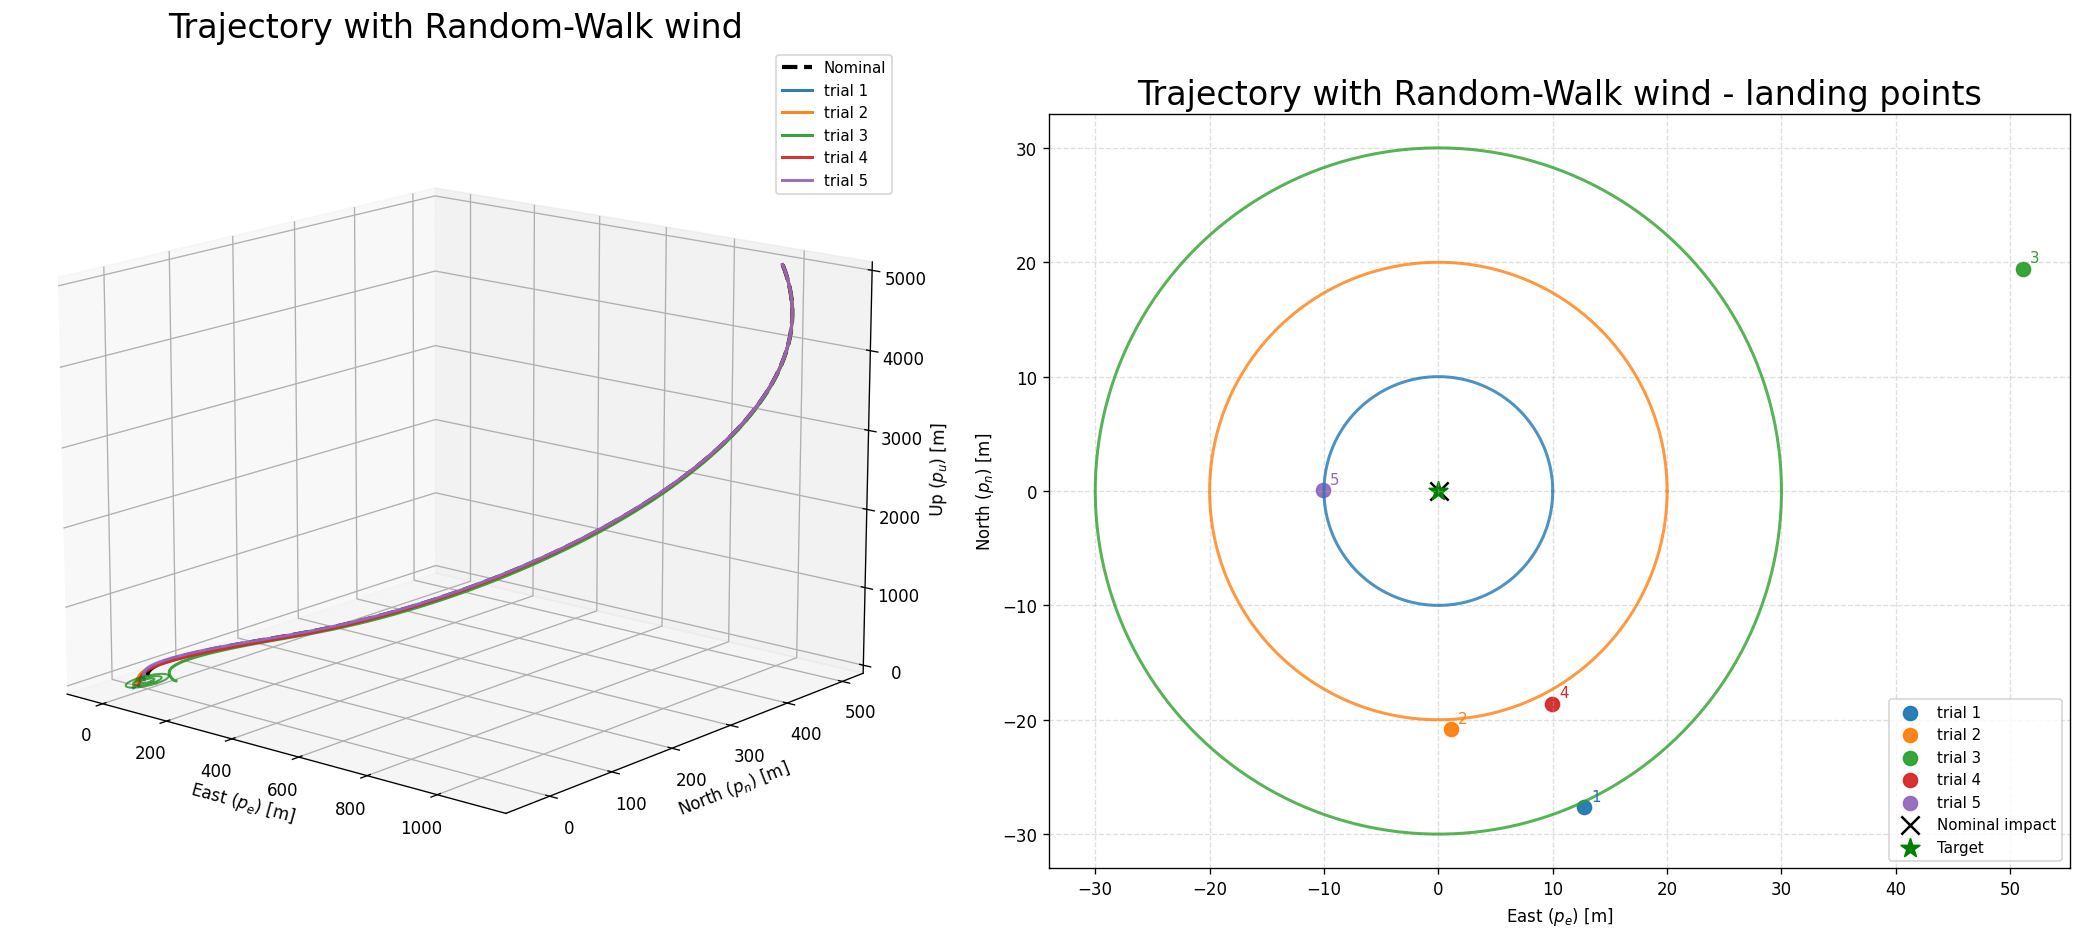

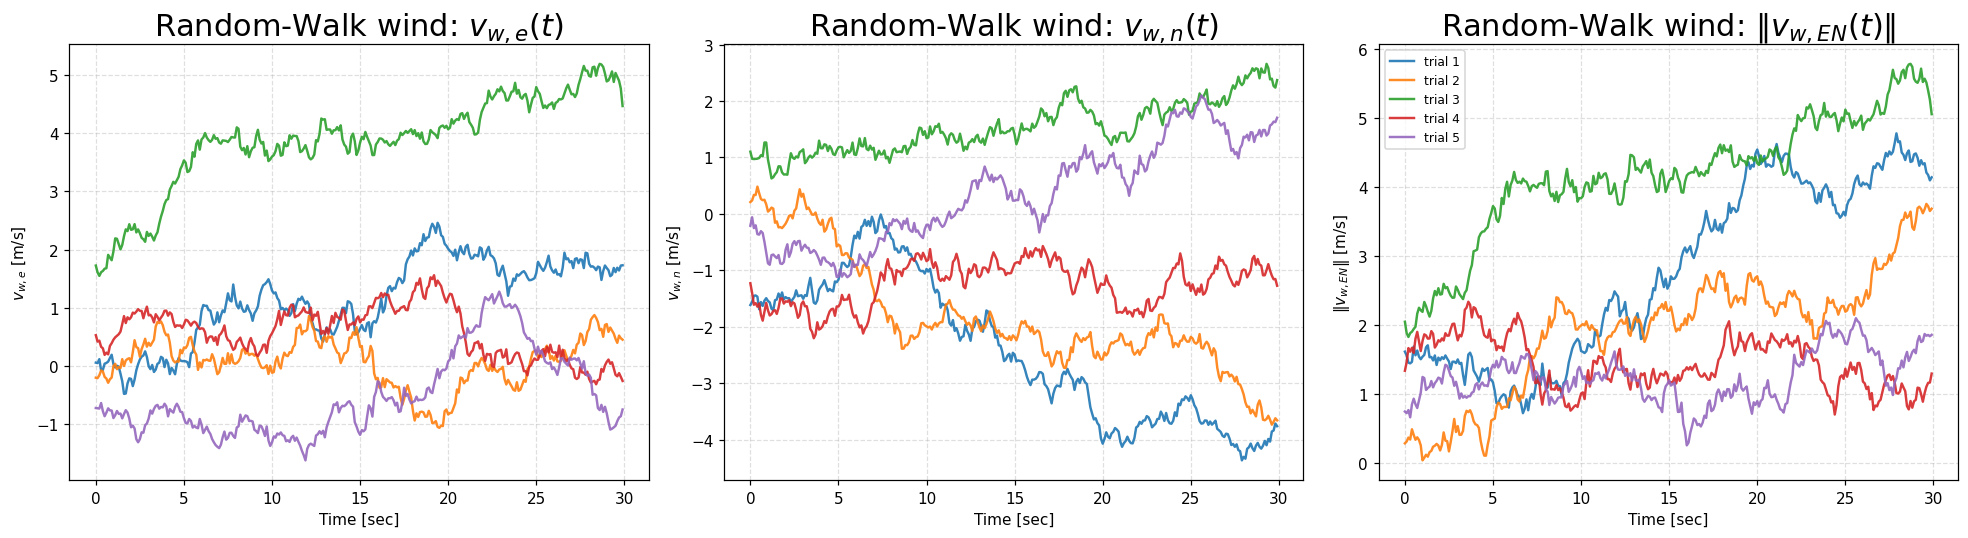

Open-loop demo radius error mean/std/max: 27.45691384560576 15.064581304177475 54.68825607099564
Open-loop demo success: 3 / 5


In [ ]:
# =========================
# [2-UPDATED] same colors for trial 1~5
# trajectory / impact / wind colors unified
# =========================

def make_trial_color_map_for_little(plot_indices):
    """
    plot_indices: e.g. [0,1,2,3,4]
    returns: {trial_idx: color}
    """
    base_colors = plt.rcParams["axes.prop_cycle"].by_key()["color"]
    return {idx: base_colors[k % len(base_colors)] for k, idx in enumerate(plot_indices)}


def simulate_wind_openloop_cut(x0, U_nom, A, B, G, b,
                               Vw_seq=None,
                               sigma0=None, sigma_step=None):
    N_local = U_nom.shape[1]

    if Vw_seq is None:
        if sigma0 is None or sigma_step is None:
            raise ValueError("Either Vw_seq or (sigma0, sigma_step) must be provided.")
        Vw_seq = generate_wind_sequence(N_local, sigma0, sigma_step)

    X = np.full((6, N_local + 1), np.nan, dtype=float)
    Vw = Vw_seq.copy()

    X[:, 0] = x0.copy()

    for t in range(N_local):
        if t > 0 and X[2, t] <= 0.0:
            break
        X[:, t + 1] = A @ X[:, t] + B @ U_nom[:, t] + G @ Vw_seq[:, t] + b

    X, Vw, _, _, _ = cut_after_ground(X, Vw=Vw)
    return X, Vw


def run_openloop_mc(M, x0, U_nom, A, B, G, b, sigma0, sigma_step):
    trajs = []
    winds = []
    for _ in range(M):
        X, Vw = simulate_wind_openloop_cut(
            x0, U_nom, A, B, G, b,
            sigma0=sigma0, sigma_step=sigma_step
        )
        trajs.append(X)
        winds.append(Vw)
    return trajs, winds


def plot_case_overview_for_little(trajs, X_nom, x_des, title="", plot_indices=None, max_plot=5):
    """
    trial 1~5 등 특정 trial만 색깔별로 trajectory/impact 표시
    plot_indices=None 이면 앞에서부터 max_plot개 사용
    """
    if plot_indices is None:
        plot_indices = np.arange(min(len(trajs), max_plot))
    else:
        plot_indices = np.array(plot_indices, dtype=int)

    trial_colors = make_trial_color_map_for_little(plot_indices)

    theta = np.linspace(0, 2*np.pi, 400)
    radii = [10, 20, 30]

    impacts = np.array([impact_point_from_traj(X) for X in trajs])
    pe_nom, pn_nom = impact_point_from_traj(X_nom)

    fig = plt.figure(figsize=(18, 8), dpi=120)

    # =========================
    # (Left) 3D trajectories
    # =========================
    ax1 = fig.add_subplot(1, 2, 1, projection="3d")
    ax1.view_init(elev=15, azim=-50, roll=0)

    ax1.plot(X_nom[0, :], X_nom[1, :], X_nom[2, :],
             "k--", linewidth=2.5, label="Nominal")

    for i in plot_indices:
        X = trajs[i]
        ax1.plot(X[0, :], X[1, :], X[2, :],
                 color=trial_colors[i],
                 linewidth=1.8, alpha=0.95,
                 label=f"trial {i+1}")

    for r in radii:
        ax1.plot(x_des[0] + r*np.cos(theta),
                 x_des[1] + r*np.sin(theta),
                 np.zeros_like(theta) + x_des[2],
                 "g", alpha=0.7, linewidth=1.2)

    ax1.set_xlabel("East $(p_e)$ [m]")
    ax1.set_ylabel("North $(p_n)$ [m]")
    ax1.set_zlabel("Up $(p_u)$ [m]")
    ax1.set_title(f"{title}", fontsize=20)
    ax1.legend(loc="best", fontsize=9)

    # =========================
    # (Right) Impact scatter
    # =========================
    ax2 = fig.add_subplot(1, 2, 2)

    # trial 1~5 impact points: same color as wind plots
    for i in plot_indices:
        pe, pn = impacts[i]
        ax2.scatter(pe, pn,
                    s=70,
                    color=trial_colors[i],
                    alpha=0.95,
                    label=f"trial {i+1}")
        ax2.text(pe + 0.6, pn + 0.6, f"{i+1}",
                 color=trial_colors[i], fontsize=9)

    ax2.scatter([pe_nom], [pn_nom], s=120, marker="x", color="k", label="Nominal impact")
    ax2.scatter([x_des[0]], [x_des[1]], s=140, marker="*", color="green", label="Target")

    for r in radii:
        ax2.plot(x_des[0] + r*np.cos(theta),
                 x_des[1] + r*np.sin(theta),
                 linewidth=1.8, alpha=0.8)

    ax2.set_aspect("equal", adjustable="box")
    ax2.set_xlabel("East $(p_e)$ [m]")
    ax2.set_ylabel("North $(p_n)$ [m]")
    ax2.set_title(f"{title} - landing points", fontsize=20)
    ax2.grid(True, linestyle="--", alpha=0.4)
    ax2.legend(loc="best", fontsize=9)

    plt.tight_layout()
    plt.show()


def plot_wind_samples_for_little(winds, ts, title="", plot_indices=None, max_plot=5):
    if plot_indices is None:
        plot_indices = np.arange(min(len(winds), max_plot))
    else:
        plot_indices = np.array(plot_indices, dtype=int)

    trial_colors = make_trial_color_map_for_little(plot_indices)
    ts_u = ts[:-1]

    fig, axes = plt.subplots(1, 3, figsize=(18, 5), dpi=110, sharex=True)

    # v_w,e
    ax = axes[0]
    for i in plot_indices:
        Vw = winds[i]
        ax.plot(ts_u, Vw[0, :],
                color=trial_colors[i],
                alpha=0.90, linewidth=1.6,
                label=f"trial {i+1}")
    ax.set_title(rf"{title}: $v_{{w,e}}(t)$", fontsize=20)
    ax.set_xlabel("Time [sec]")
    ax.set_ylabel(r"$v_{w,e}$ [m/s]")
    ax.grid(True, linestyle="--", alpha=0.4)

    # v_w,n
    ax = axes[1]
    for i in plot_indices:
        Vw = winds[i]
        ax.plot(ts_u, Vw[1, :],
                color=trial_colors[i],
                alpha=0.90, linewidth=1.6,
                label=f"trial {i+1}")
    ax.set_title(rf"{title}: $v_{{w,n}}(t)$", fontsize=20)
    ax.set_xlabel("Time [sec]")
    ax.set_ylabel(r"$v_{w,n}$ [m/s]")
    ax.grid(True, linestyle="--", alpha=0.4)

    # |v_w,EN|
    ax = axes[2]
    for i in plot_indices:
        Vw = winds[i]
        vw_mag = np.sqrt(Vw[0, :]**2 + Vw[1, :]**2)
        ax.plot(ts_u, vw_mag,
                color=trial_colors[i],
                alpha=0.90, linewidth=1.6,
                label=f"trial {i+1}")
    ax.set_title(rf"{title}: $\|v_{{w,EN}}(t)\|$", fontsize=20)
    ax.set_xlabel("Time [sec]")
    ax.set_ylabel(r"$\|v_{w,EN}\|$ [m/s]")
    ax.grid(True, linestyle="--", alpha=0.4)
    ax.legend(fontsize=8, loc="best")

    plt.tight_layout()
    plt.show()

# =========================
# [2-run] quick demo for Section II / III figures
# =========================
n_show = 5

trajs_demo, winds_demo = run_openloop_mc(
    n_show, x0, U_nom, A, B, G, b, sigma0, sigma_step
)

plot_case_overview_for_little(trajs_demo, X_nom, x_des, title="Trajectory with Random-Walk wind", max_plot=n_show)
plot_wind_samples_for_little(winds_demo, ts, title="Random-Walk wind", max_plot=n_show)

rad_err_demo, vtouch_demo, suc_demo = compute_case_metrics(trajs_demo, x_des, R_SUCCESS, V_SUCCESS)
print("Open-loop demo radius error mean/std/max:",
      np.nanmean(rad_err_demo), np.nanstd(rad_err_demo), np.nanmax(rad_err_demo))
print("Open-loop demo success:", int(np.sum(suc_demo)), "/", len(suc_demo))

## 3. 4절 확장상태 Kalman Filter

In [ ]:
# =========================
# [3] augmented-state KF model
# x_tilde = [x_t; v_w,t]
# =========================

# measurement model
C = np.hstack([np.eye(3), np.zeros((3, 3))])           # shape (3, 6)
C_tilde = np.hstack([C, np.zeros((3, 3))])             # shape (3, 9)

# process / measurement covariances
Q_x = 1e-6 * np.eye(6)
Q_w = np.diag([sigma_step**2, sigma_step**2, 0.0])
Q_tilde = np.block([
    [Q_x,               np.zeros((6, 3))],
    [np.zeros((3, 6)),  Q_w]
])

R_meas = (sigma_gps**2) * np.eye(3)

# initial covariance
P0 = np.diag([100, 100, 100, 100, 100, 100, 1, 1, 1]).astype(float)

# augmented dynamics
A_tilde = np.block([
    [A, G],
    [np.zeros((3, 6)), np.eye(3)]
])

B_tilde = np.vstack([B, np.zeros((3, 3))])
b_tilde = np.hstack([b, np.zeros(3)])

print("A_tilde shape =", A_tilde.shape)
print("B_tilde shape =", B_tilde.shape)
print("C_tilde shape =", C_tilde.shape)
print("Q_tilde shape =", Q_tilde.shape)
print("R_meas shape =", R_meas.shape)

A_tilde shape = (9, 9)
B_tilde shape = (9, 3)
C_tilde shape = (3, 9)
Q_tilde shape = (9, 9)
R_meas shape = (3, 3)


## 4. 5-6절 칼만필터 + 보정 시뮬레이션

In [ ]:
def simulate_kf_wind_comp(
    x0, U_nom, A, B, G, b,
    u_min, u_max,
    Vw_seq=None,
    meas_noise_seq=None,
    compensate=True,
    use_true_wind=False,
    X_ref=None,
    K_fb=None,
    clip_control=True,
    R_meas=R_meas,
    Q_tilde=Q_tilde,
    P0=P0
):
    N_local = U_nom.shape[1]

    if Vw_seq is None:
        Vw_seq = generate_wind_sequence(N_local, sigma0, sigma_step)

    if meas_noise_seq is None:
        meas_noise_seq = generate_meas_noise_sequence(N_local, R_meas)

    X = np.full((6, N_local + 1), np.nan, dtype=float)
    Vw = Vw_seq.copy()
    Xhat = np.full((9, N_local + 1), np.nan, dtype=float)
    Ucmd = np.full((3, N_local), np.nan, dtype=float)
    Y = np.full((3, N_local), np.nan, dtype=float)

    X[:, 0] = x0.copy()

    xbar = np.zeros(9, dtype=float)
    xbar[:6] = x0.copy()
    xbar[8] = 0.0   # v_w,u = 0 고정
    Pbar = P0.copy()
    Pbar[8, :] = 0.0
    Pbar[:, 8] = 0.0

    I9 = np.eye(9)

    for t in range(N_local):
        if t > 0 and X[2, t] <= 0.0:
            break

        # 1) measurement update
        y = C @ X[:, t] + meas_noise_seq[:, t]
        Y[:, t] = y

        S = C_tilde @ Pbar @ C_tilde.T + R_meas
        Kk = Pbar @ C_tilde.T @ np.linalg.inv(S)
        innov = y - C_tilde @ xbar

        xhat = xbar + Kk @ innov
        Phat = (I9 - Kk @ C_tilde) @ Pbar

        # horizontal-wind-only 가정 강제
        xhat[8] = 0.0
        Phat[8, :] = 0.0
        Phat[:, 8] = 0.0

        Xhat[:, t] = xhat

        # 2) control
        wind_for_comp = Vw_seq[:, t] if use_true_wind else xhat[6:9]
        wind_for_comp = wind_for_comp.copy()
        wind_for_comp[2] = 0.0   # 수직축 보정 금지

        u_cmd = U_nom[:, t].copy()

        if compensate:
            u_cmd = u_cmd - gamma * wind_for_comp

        if (K_fb is not None) and (X_ref is not None):
            u_cmd = u_cmd - K_fb @ (xhat[:6] - X_ref[:, t])

        if clip_control:
            u_cmd = np.clip(u_cmd, u_min, u_max)

        Ucmd[:, t] = u_cmd

        # 3) true plant propagation
        X[:, t + 1] = A @ X[:, t] + B @ u_cmd + G @ Vw_seq[:, t] + b

        # 4) prediction
        xbar = A_tilde @ xhat + B_tilde @ u_cmd + b_tilde
        Pbar = A_tilde @ Phat @ A_tilde.T + Q_tilde

        # horizontal-wind-only 가정 강제
        xbar[8] = 0.0
        Pbar[8, :] = 0.0
        Pbar[:, 8] = 0.0

        Xhat[:, t + 1] = xbar

    X, Vw, Xhat, Ucmd, Y = cut_after_ground(X, Vw=Vw, Xhat=Xhat, Ucmd=Ucmd, Y=Y)
    return X, Vw, Xhat, Ucmd, Y

## 6. 6절 통합 시뮬레이션

In [ ]:
# =========================
# [6] same-wind / same-noise bank experiments
# Baseline      : u_cmd = u_nom
# Proposed      : u_cmd = u_nom - gamma * vhat_w
# Optional      : u_cmd = u_nom - gamma * vhat_w - K_fb (xhat - x_ref)
# =========================

# storing X / Xhat / Ucmd for many trials is memory-heavy
# start with M = 1000; increase only if RAM allows


M = 1000

wind_bank = [generate_wind_sequence(N, sigma0, sigma_step) for _ in range(M)]
noise_bank = [generate_meas_noise_sequence(N, R_meas) for _ in range(M)]

trajs_base, winds_base, xhats_base, ucmds_base = [], [], [], []
trajs_comp, winds_comp, xhats_comp, ucmds_comp = [], [], [], []
trajs_compfb, winds_compfb, xhats_compfb, ucmds_compfb = [], [], [], []

for i in range(M):
    Vw_seq = wind_bank[i]
    noise_seq = noise_bank[i]

    # 1) Baseline: no compensation
    X, Vw, Xhat, Ucmd, _ = simulate_kf_wind_comp(
        x0, U_nom, A, B, G, b,
        u_min, u_max,
        Vw_seq=Vw_seq,
        meas_noise_seq=noise_seq,
        compensate=False,
        use_true_wind=False,
        X_ref=None,
        K_fb=None,
        clip_control=True
    )
    trajs_base.append(X)
    winds_base.append(Vw)
    xhats_base.append(Xhat)
    ucmds_base.append(Ucmd)

    # 2) Proposed: estimated wind compensation only
    X, Vw, Xhat, Ucmd, _ = simulate_kf_wind_comp(
        x0, U_nom, A, B, G, b,
        u_min, u_max,
        Vw_seq=Vw_seq,
        meas_noise_seq=noise_seq,
        compensate=True,
        use_true_wind=False,
        X_ref=None,
        K_fb=None,
        clip_control=True
    )
    trajs_comp.append(X)
    winds_comp.append(Vw)
    xhats_comp.append(Xhat)
    ucmds_comp.append(Ucmd)

    # 3) Optional: compensation + tracking feedback
    X, Vw, Xhat, Ucmd, _ = simulate_kf_wind_comp(
        x0, U_nom, A, B, G, b,
        u_min, u_max,
        Vw_seq=Vw_seq,
        meas_noise_seq=noise_seq,
        compensate=True,
        use_true_wind=False,
        X_ref=X_ref,
        clip_control=True
    )
    trajs_compfb.append(X)
    winds_compfb.append(Vw)
    xhats_compfb.append(Xhat)
    ucmds_compfb.append(Ucmd)

print("done:", M)

done: 1000


In [ ]:
# proposed case에서 estimated vertical wind가 실제로 얼마나 생기는지
vwu_hat_mean = np.mean([
    np.nanmean(np.abs(Xhat[8, :-1])) for Xhat in xhats_comp
])
print("mean |vhat_w_u| =", vwu_hat_mean)

# proposed case에서 vertical input이 nominal과 얼마나 달라졌는지
du_u_mean = np.mean([
    np.nanmean(np.abs(Ucmd[2, :] - U_nom[2, :])) for Ucmd in ucmds_comp
])
print("mean |u_cmd,u - u_nom,u| =", du_u_mean)

mean |vhat_w_u| = 0.0
mean |u_cmd,u - u_nom,u| = 0.0


## 7. 7-8절 성능 뽑기

[No compensation]
  success rate      : 72.20%
  mean radius error : 23.271 m
  std  radius error : 12.289 m
  max  radius error : 70.887 m
  mean |v_u|        : 1.025 m/s

[KF compensation]
  success rate      : 95.60%
  mean radius error : 14.533 m
  std  radius error : 7.857 m
  max  radius error : 45.949 m
  mean |v_u|        : 1.025 m/s



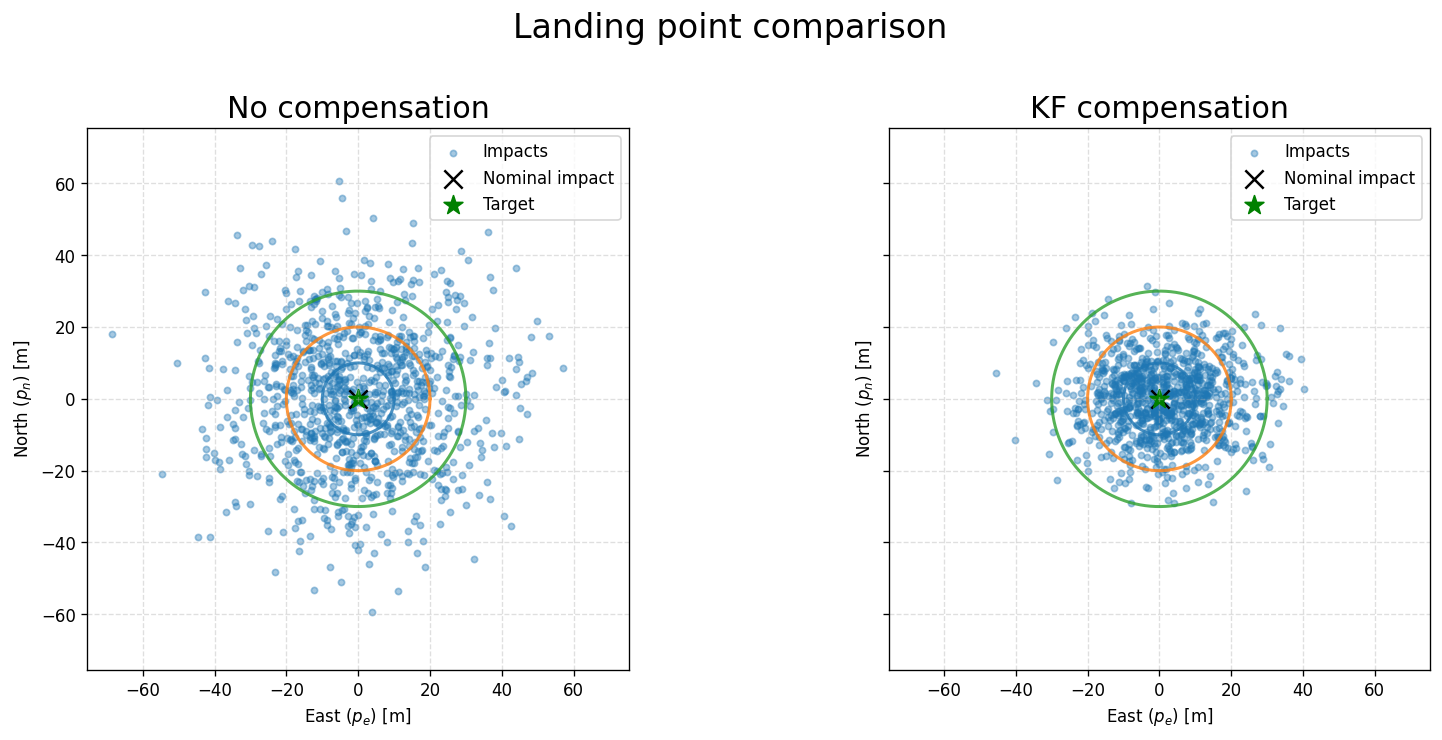

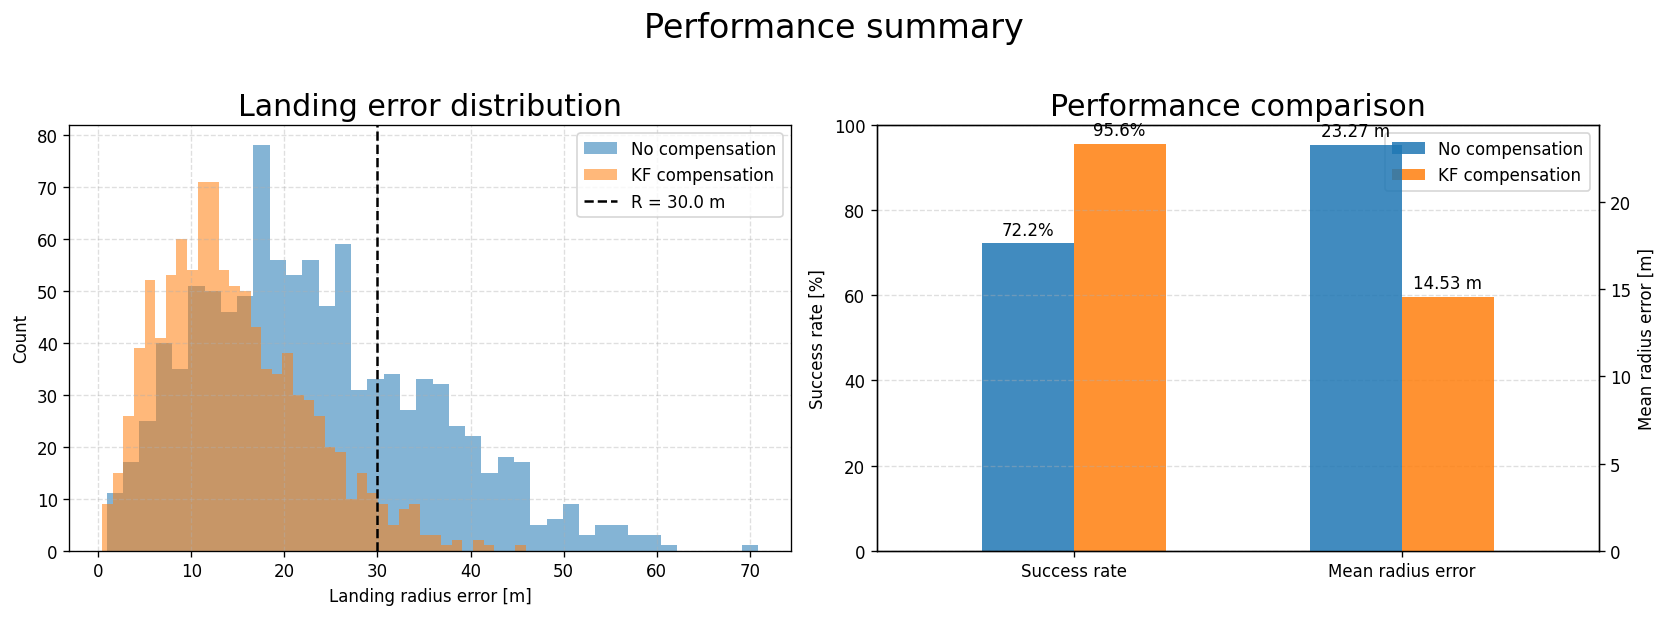

In [ ]:
# =========================
# [7] summary statistics + 1x2 plots
# =========================

def print_case_summary(name, trajs, x_des, radius=R_SUCCESS, v_tol=V_SUCCESS):
    err, vtouch, suc = compute_case_metrics(trajs, x_des, radius, v_tol)

    print(f"[{name}]")
    print(f"  success rate      : {100.0*np.mean(suc):.2f}%")
    print(f"  mean radius error : {np.nanmean(err):.3f} m")
    print(f"  std  radius error : {np.nanstd(err):.3f} m")
    print(f"  max  radius error : {np.nanmax(err):.3f} m")
    print(f"  mean |v_u|        : {np.nanmean(vtouch):.3f} m/s")
    print()

    return err, vtouch, suc


# -------------------------
# metrics
# -------------------------
err_base, vtouch_base, suc_base = print_case_summary(
    "No compensation", trajs_base, x_des, R_SUCCESS, V_SUCCESS
)

err_comp, vtouch_comp, suc_comp = print_case_summary(
    "KF compensation", trajs_comp, x_des, R_SUCCESS, V_SUCCESS
)


# =========================
# (A) Impact points: 1x2 subplot
# same x/y limits for both panels
# =========================
def plot_impact_points_1x2(trajs_base, trajs_comp, X_nom, x_des,
                           title_left="No compensation",
                           title_right="KF compensation",
                           min_half_width=40.0,
                           margin_ratio=0.10):
    theta = np.linspace(0, 2*np.pi, 400)
    radii = [10, 20, 30]

    impacts_base = np.array([impact_point_from_traj(X) for X in trajs_base], dtype=float)
    impacts_comp = np.array([impact_point_from_traj(X) for X in trajs_comp], dtype=float)
    pe_nom, pn_nom = impact_point_from_traj(X_nom)

    # -------------------------
    # common square limits
    # target 중심으로 동일한 lim 설정
    # -------------------------
    pe_all = np.concatenate([
        impacts_base[np.isfinite(impacts_base[:, 0]), 0],
        impacts_comp[np.isfinite(impacts_comp[:, 0]), 0],
        np.array([pe_nom, x_des[0]])
    ])
    pn_all = np.concatenate([
        impacts_base[np.isfinite(impacts_base[:, 1]), 1],
        impacts_comp[np.isfinite(impacts_comp[:, 1]), 1],
        np.array([pn_nom, x_des[1]])
    ])

    max_dev_e = np.max(np.abs(pe_all - x_des[0]))
    max_dev_n = np.max(np.abs(pn_all - x_des[1]))

    half_width = max(max_dev_e, max_dev_n, radii[-1])
    half_width = max(min_half_width, (1.0 + margin_ratio) * half_width)

    xlim = (x_des[0] - half_width, x_des[0] + half_width)
    ylim = (x_des[1] - half_width, x_des[1] + half_width)

    fig, axes = plt.subplots(1, 2, figsize=(14, 6), dpi=120, sharex=True, sharey=True)

    # -------------------------
    # Left: No compensation
    # -------------------------
    ax = axes[0]
    mask = np.isfinite(impacts_base[:, 0]) & np.isfinite(impacts_base[:, 1])

    ax.scatter(
        impacts_base[mask, 0], impacts_base[mask, 1],
        s=14, alpha=0.40, label="Impacts"
    )
    ax.scatter([pe_nom], [pn_nom], s=120, marker="x", color="k", label="Nominal impact")
    ax.scatter([x_des[0]], [x_des[1]], s=140, marker="*", color="green", label="Target")

    for r in radii:
        ax.plot(
            x_des[0] + r*np.cos(theta),
            x_des[1] + r*np.sin(theta),
            linewidth=1.8, alpha=0.8
        )

    ax.set_aspect("equal", adjustable="box")
    ax.set_xlim(xlim)
    ax.set_ylim(ylim)
    ax.set_xlabel("East $(p_e)$ [m]")
    ax.set_ylabel("North $(p_n)$ [m]")
    ax.set_title(title_left, fontsize=18)
    ax.grid(True, linestyle="--", alpha=0.4)
    ax.legend(loc="best")

    # -------------------------
    # Right: KF compensation
    # -------------------------
    ax = axes[1]
    mask = np.isfinite(impacts_comp[:, 0]) & np.isfinite(impacts_comp[:, 1])

    ax.scatter(
        impacts_comp[mask, 0], impacts_comp[mask, 1],
        s=14, alpha=0.40, label="Impacts"
    )
    ax.scatter([pe_nom], [pn_nom], s=120, marker="x", color="k", label="Nominal impact")
    ax.scatter([x_des[0]], [x_des[1]], s=140, marker="*", color="green", label="Target")

    for r in radii:
        ax.plot(
            x_des[0] + r*np.cos(theta),
            x_des[1] + r*np.sin(theta),
            linewidth=1.8, alpha=0.8
        )

    ax.set_aspect("equal", adjustable="box")
    ax.set_xlim(xlim)
    ax.set_ylim(ylim)
    ax.set_xlabel("East $(p_e)$ [m]")
    ax.set_ylabel("North $(p_n)$ [m]")
    ax.set_title(title_right, fontsize=18)
    ax.grid(True, linestyle="--", alpha=0.4)
    ax.legend(loc="best")

    plt.suptitle("Landing point comparison", fontsize=20, y=1.02)
    plt.tight_layout()
    plt.show()


# =========================
# (B) Histogram + Success-rate bar: 1x2 subplot
# =========================
def plot_performance_1x2(err_base, err_comp, suc_base, suc_comp,
                        R_SUCCESS=R_SUCCESS):
    fig, axes = plt.subplots(1, 2, figsize=(14, 5), dpi=120)

    # -------------------------
    # colors (histogram / bar 공통)
    # -------------------------
    base_colors = plt.rcParams["axes.prop_cycle"].by_key()["color"]
    c_no = base_colors[0]   # No compensation
    c_kf = base_colors[1]   # KF compensation

    # -------------------------
    # Left: histogram
    # -------------------------
    ax = axes[0]
    bins = 40

    ax.hist(
        err_base[np.isfinite(err_base)],
        bins=bins, alpha=0.55, label="No compensation", color=c_no
    )
    ax.hist(
        err_comp[np.isfinite(err_comp)],
        bins=bins, alpha=0.55, label="KF compensation", color=c_kf
    )
    ax.axvline(R_SUCCESS, color="k", linestyle="--", label=f"R = {R_SUCCESS:.1f} m")

    ax.set_xlabel("Landing radius error [m]")
    ax.set_ylabel("Count")
    ax.set_title("Landing error distribution", fontsize=18)
    ax.grid(True, linestyle="--", alpha=0.4)
    ax.legend(loc="best")

    # -------------------------
    # Right: x축 = metric, bars = No / KF
    # -------------------------
    ax1 = axes[1]          # success rate axis [%]
    ax2 = ax1.twinx()      # mean radius error axis [m]

    metrics = ["Success rate", "Mean radius error"]
    x = np.array([0.0, 1.0])
    width = 0.28

    rates = np.array([
        100.0 * np.mean(suc_base),
        100.0 * np.mean(suc_comp),
    ])

    mean_err = np.array([
        np.nanmean(err_base),
        np.nanmean(err_comp),
    ])

    # category 1: success rate  -> ax1
    bars_rate_no = ax1.bar(
        x[0] - width/2, rates[0], width,
        color=c_no, alpha=0.85, label="No compensation"
    )
    bars_rate_kf = ax1.bar(
        x[0] + width/2, rates[1], width,
        color=c_kf, alpha=0.85, label="KF compensation"
    )

    # category 2: mean radius error -> ax2
    bars_err_no = ax2.bar(
        x[1] - width/2, mean_err[0], width,
        color=c_no, alpha=0.85
    )
    bars_err_kf = ax2.bar(
        x[1] + width/2, mean_err[1], width,
        color=c_kf, alpha=0.85
    )

    ax1.set_xticks(x)
    ax1.set_xticklabels(metrics)
    ax1.set_ylabel("Success rate [%]")
    ax2.set_ylabel("Mean radius error [m]")
    ax1.set_ylim(0, 100)

    ax1.set_title("Performance comparison", fontsize=18)
    ax1.grid(True, axis="y", linestyle="--", alpha=0.4)
    ax1.set_xlim(-0.6, 1.6)

    # 값 표시
    for bar, val in zip([bars_rate_no[0], bars_rate_kf[0]], rates):
        ax1.text(
            bar.get_x() + bar.get_width()/2,
            bar.get_height() + 1.0,
            f"{val:.1f}%",
            ha="center", va="bottom", fontsize=10
        )

    for bar, val in zip([bars_err_no[0], bars_err_kf[0]], mean_err):
        ax2.text(
            bar.get_x() + bar.get_width()/2,
            bar.get_height() + 0.3,
            f"{val:.2f} m",
            ha="center", va="bottom", fontsize=10
        )

    ax1.legend(loc="upper right")

    plt.suptitle("Performance summary", fontsize=20, y=1.02)
    plt.tight_layout()
    plt.show()

# =========================
# run
# =========================
plot_impact_points_1x2(
    trajs_base, trajs_comp, X_nom, x_des,
    title_left="No compensation",
    title_right="KF compensation"
)

plot_performance_1x2(
    err_base, err_comp, suc_base, suc_comp,
    R_SUCCESS=R_SUCCESS
)

## 8. 비교, 분석

SS (both success): 722
FF (both fail)   : 44
FS (Base fail, comp success): 234
SF (Base success, comp fail): 0
Representative indices (1-based):
  FS: 884
  SF: None
  SS: 759
  FF: 241

[NO comp FAIL, KF comp SUCCESS] idx=884
  No comp: success=False, err=30.225 m
  KF comp: success=True, err=13.081 m


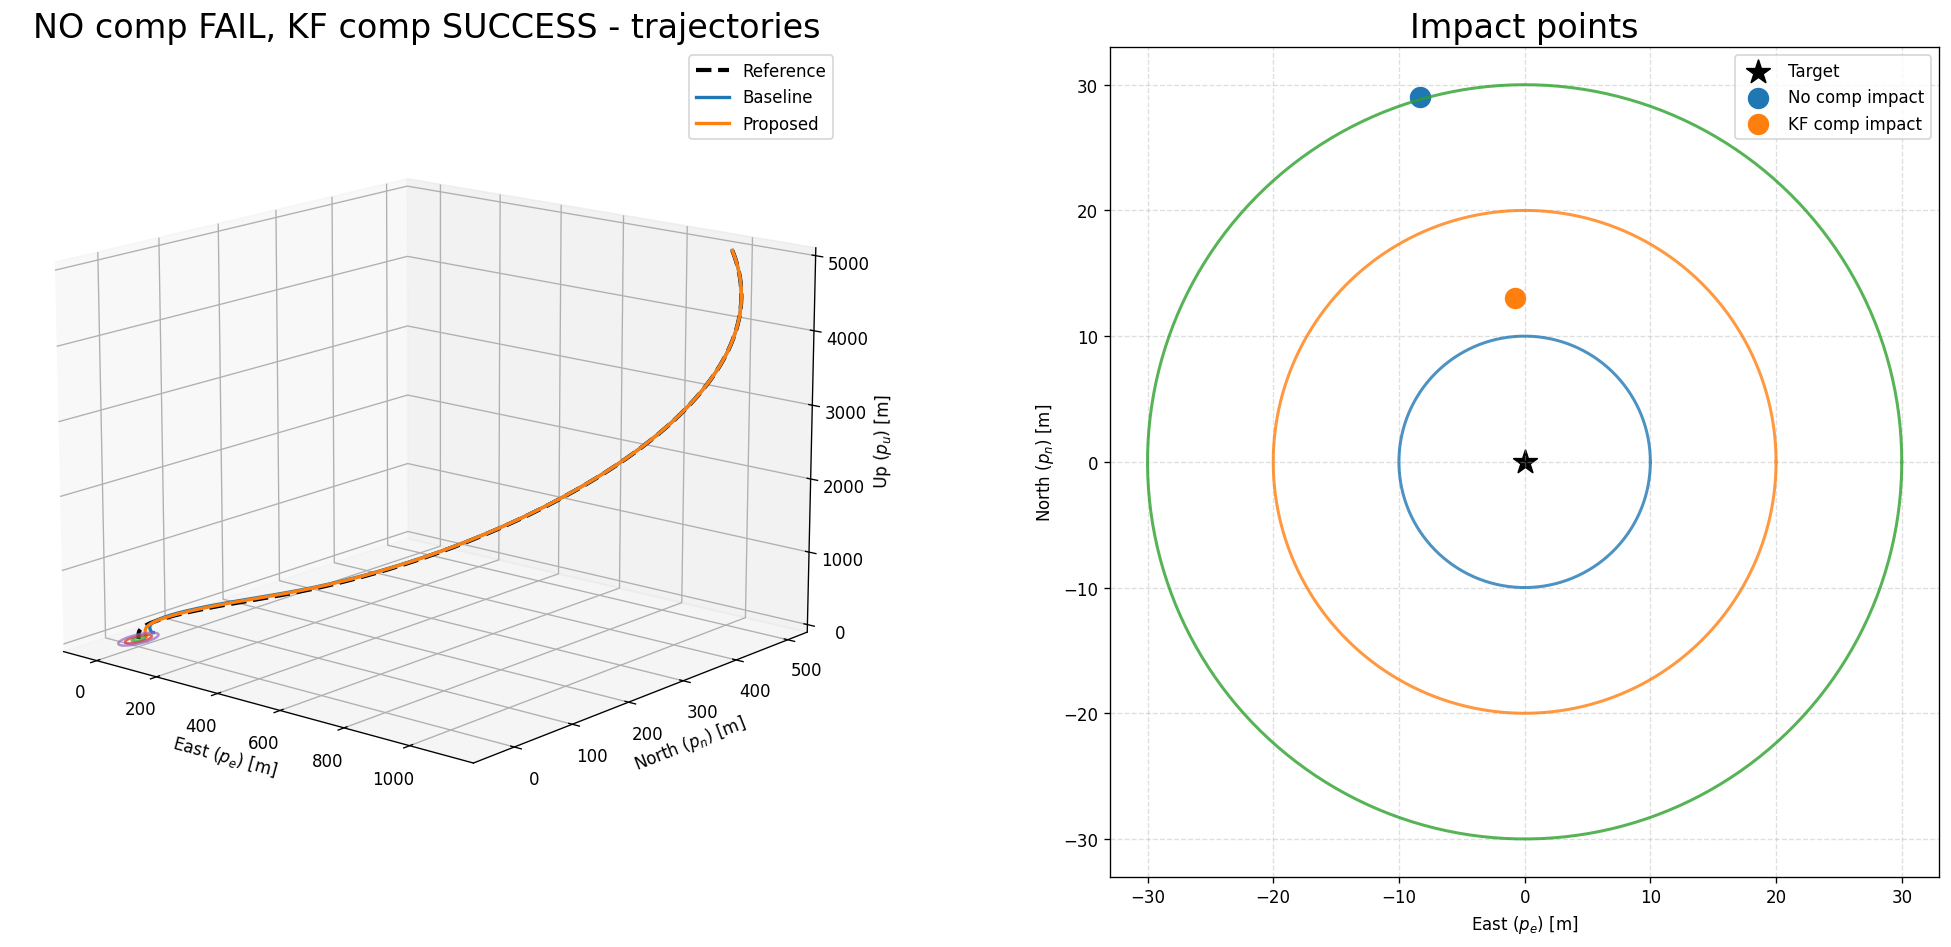

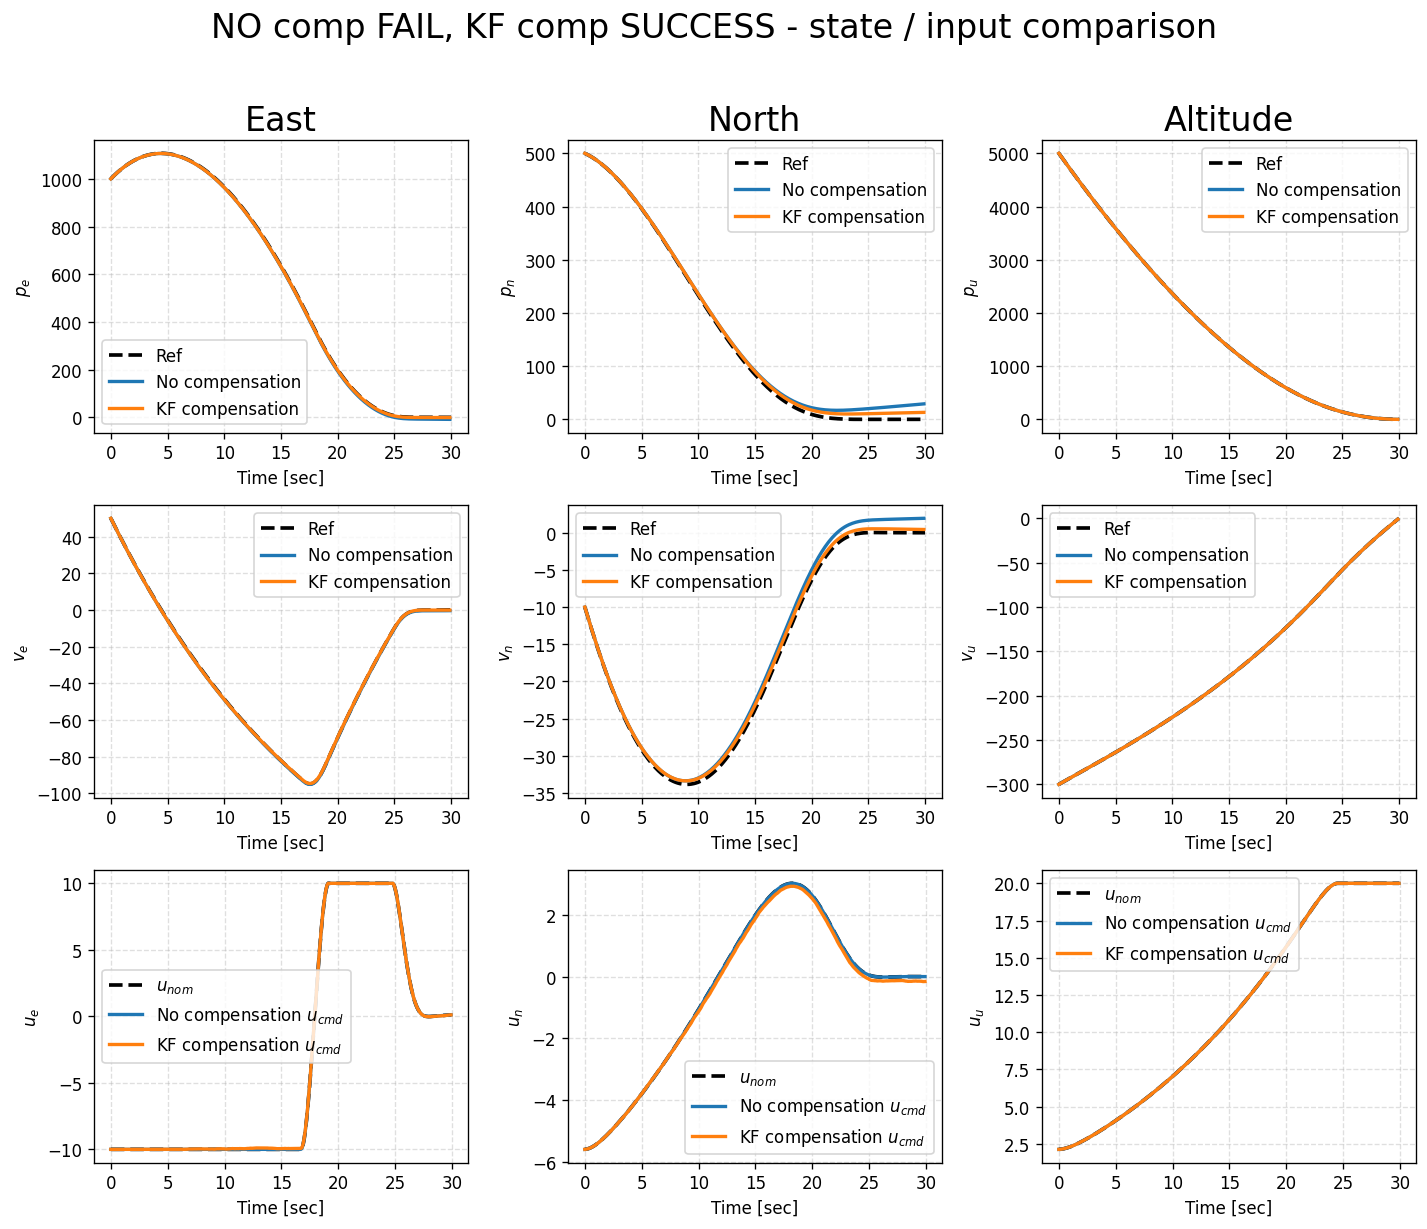

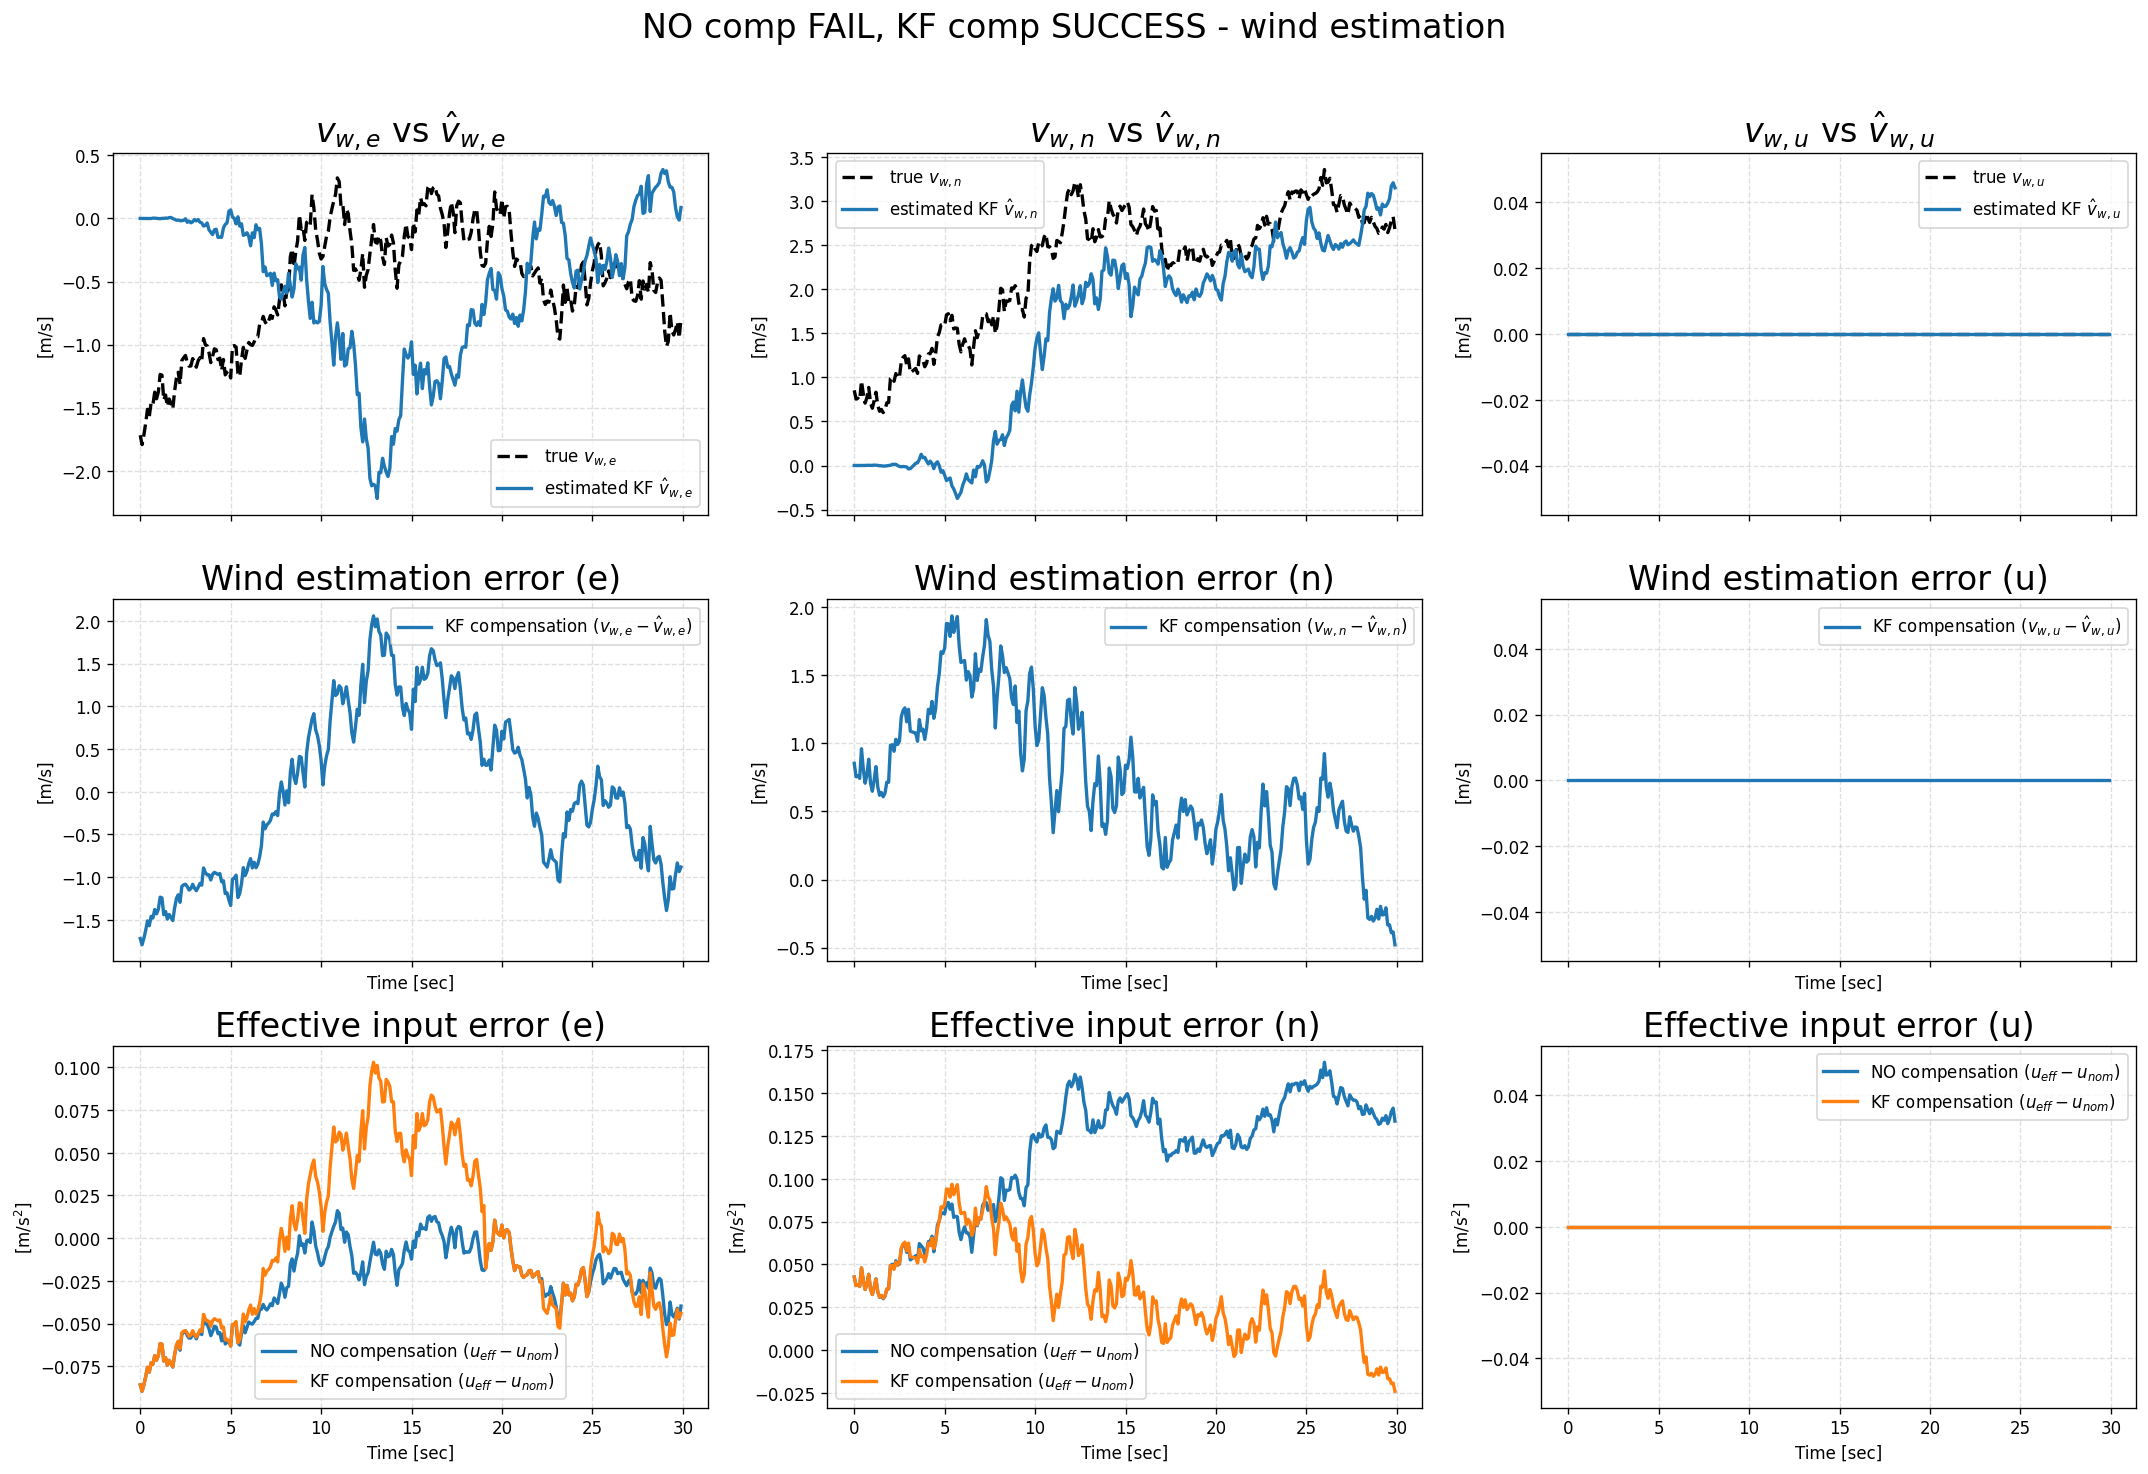

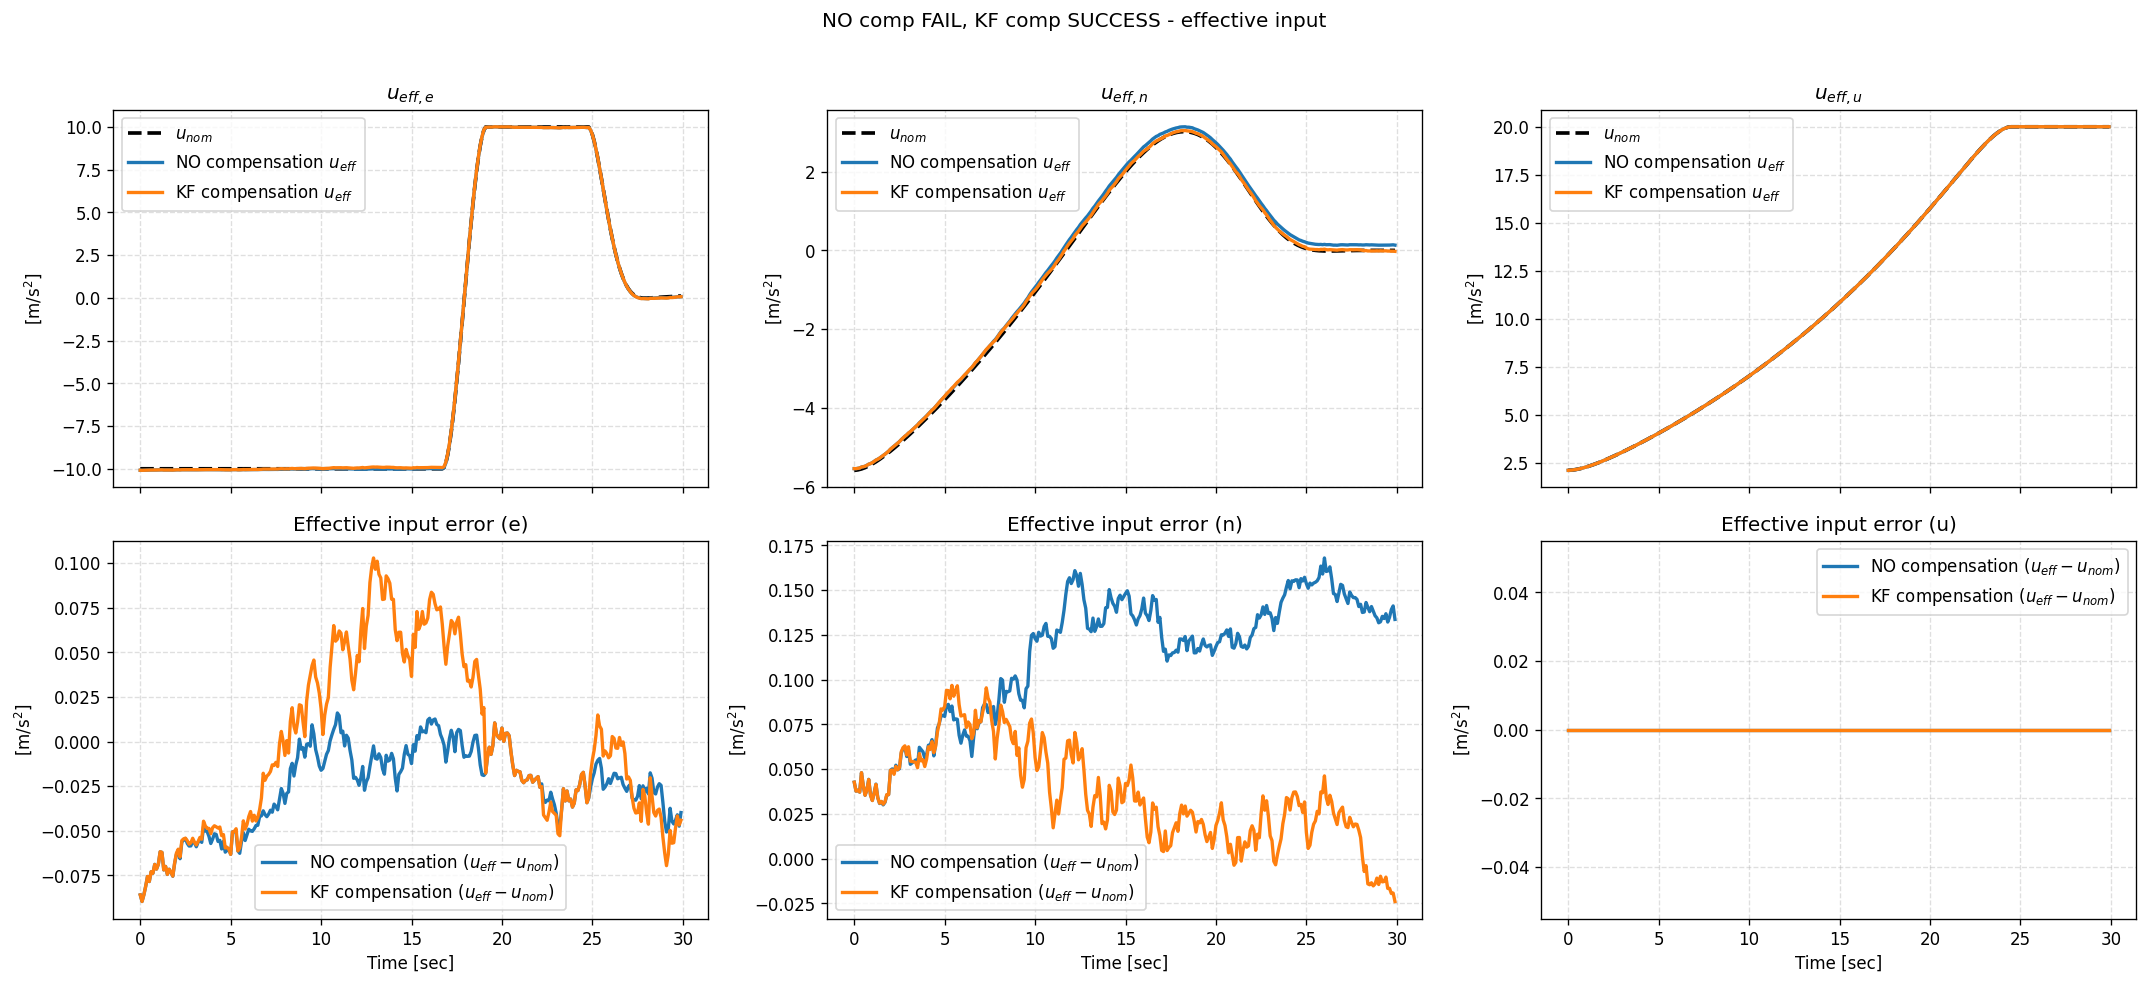

[SF: NO comp SUCCESS, KF comp FAIL] No sample found.

[SS: BOTH SUCCESS] idx=759
  No comp: success=True, err=0.940 m
  KF comp: success=True, err=0.444 m


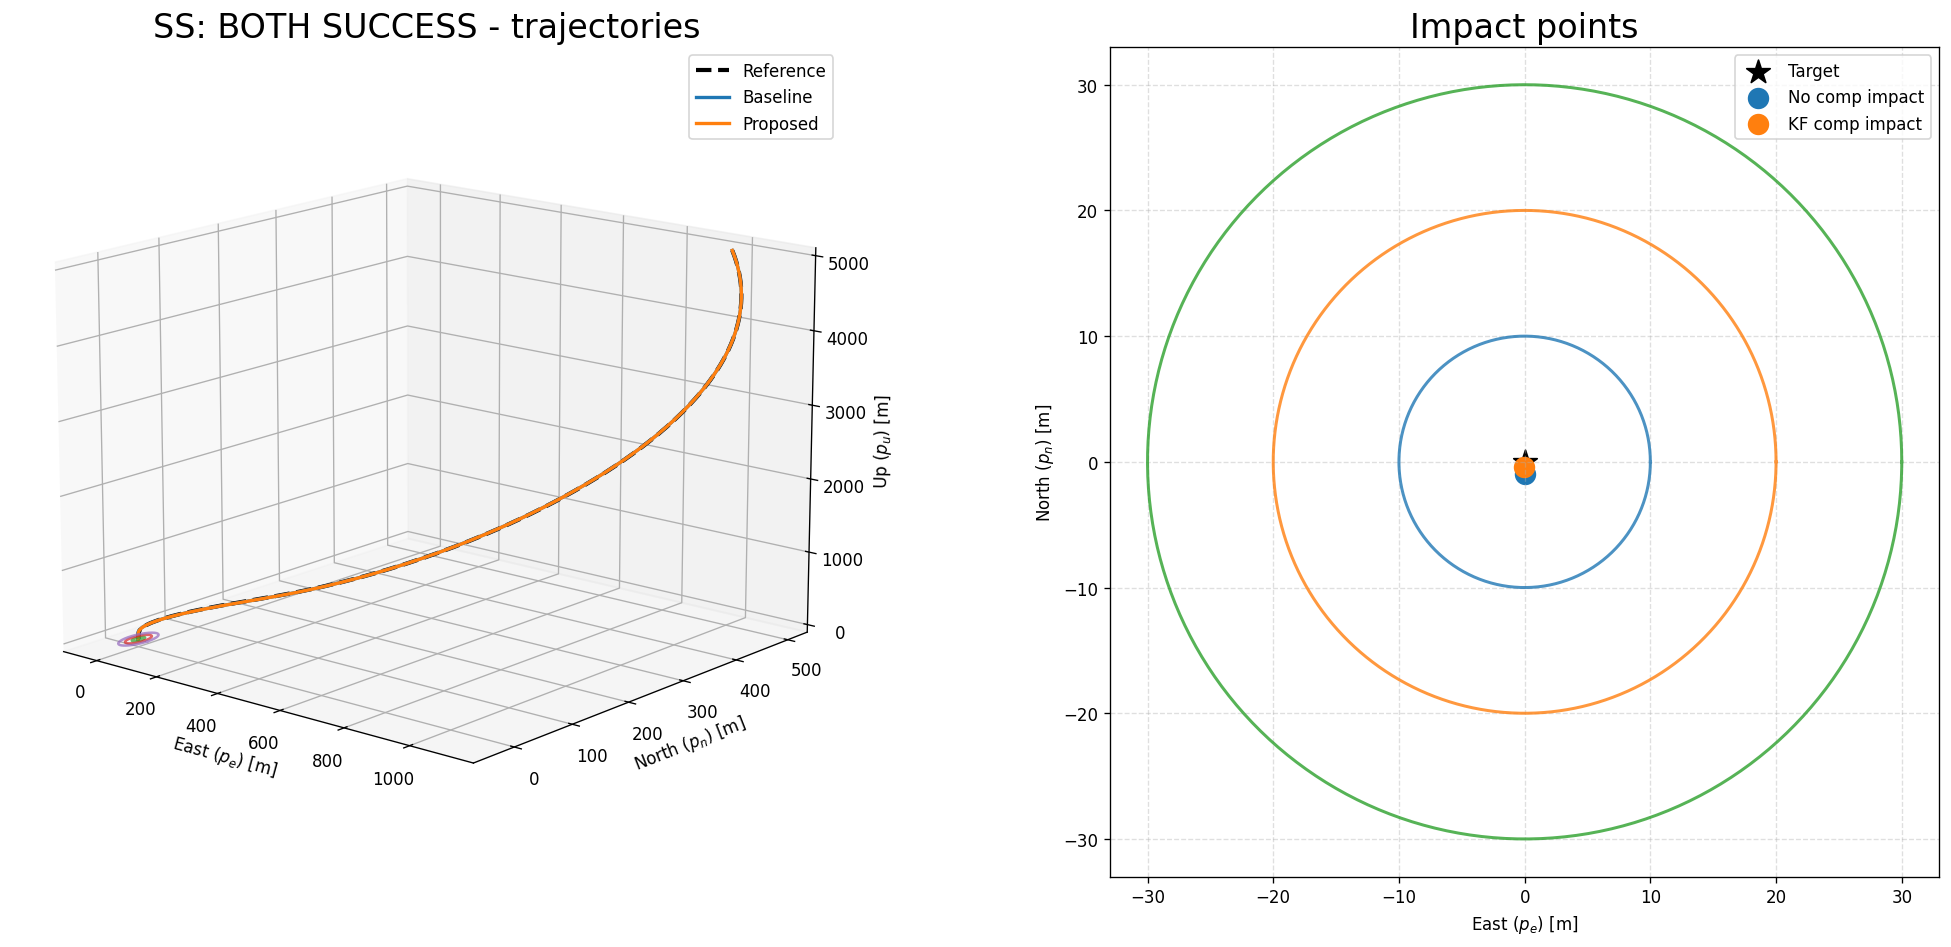

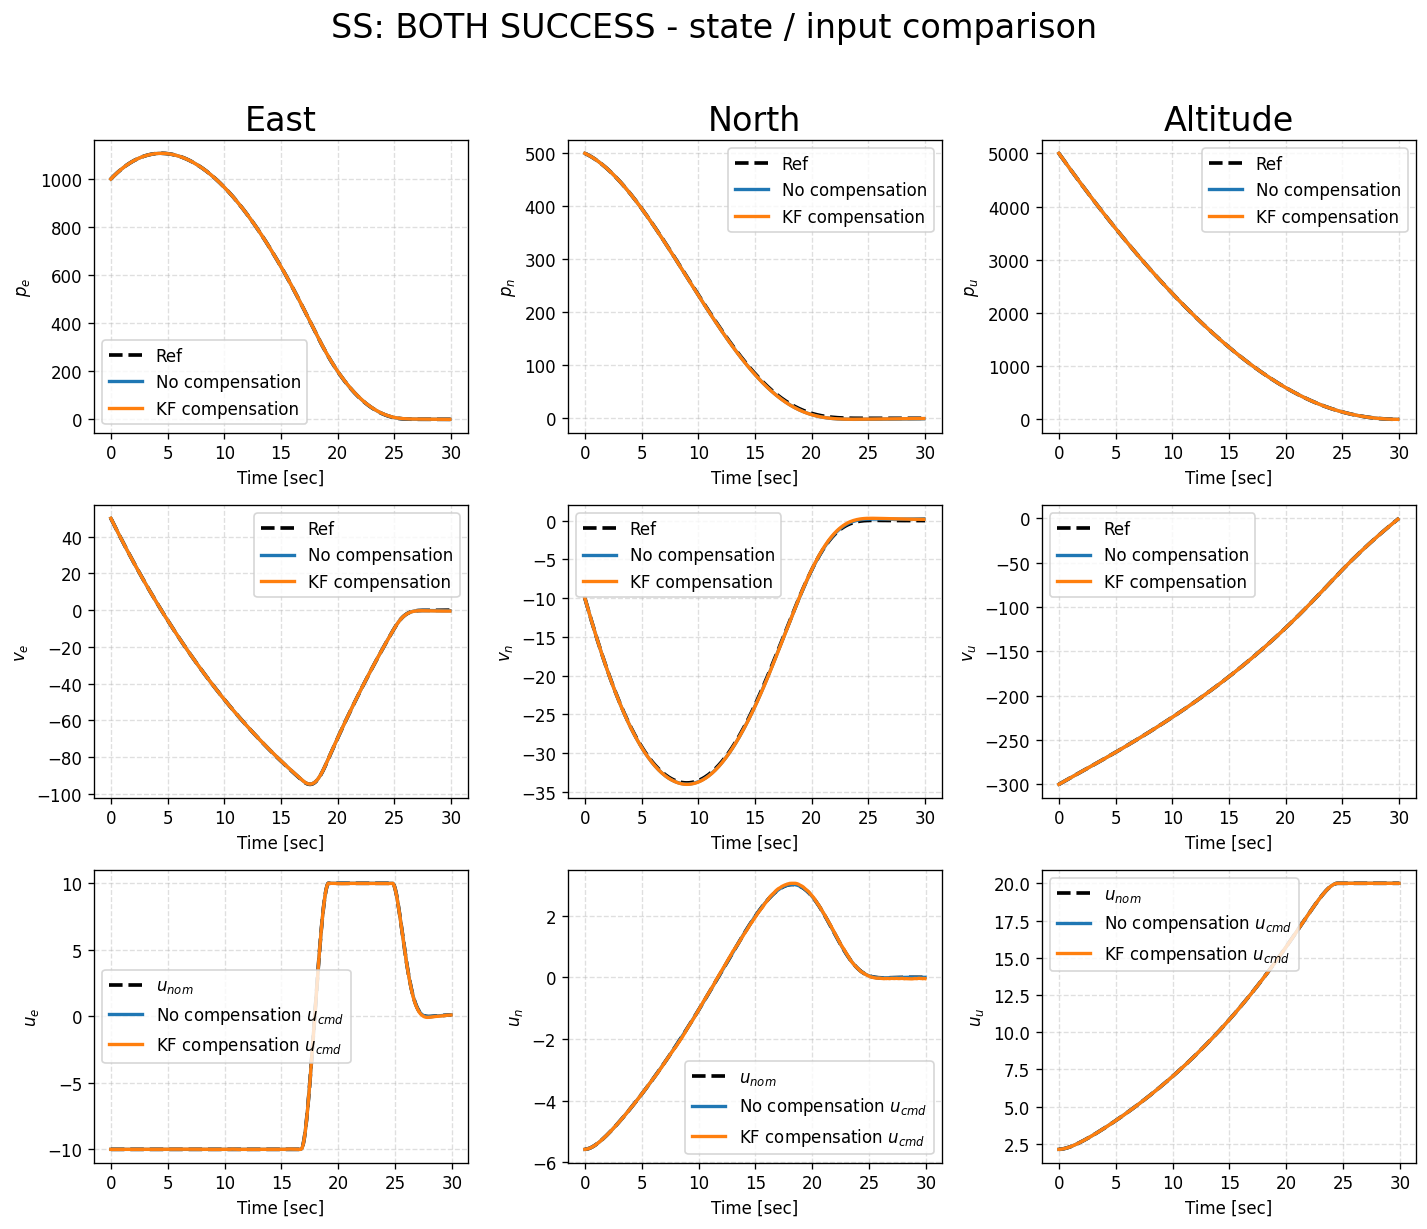

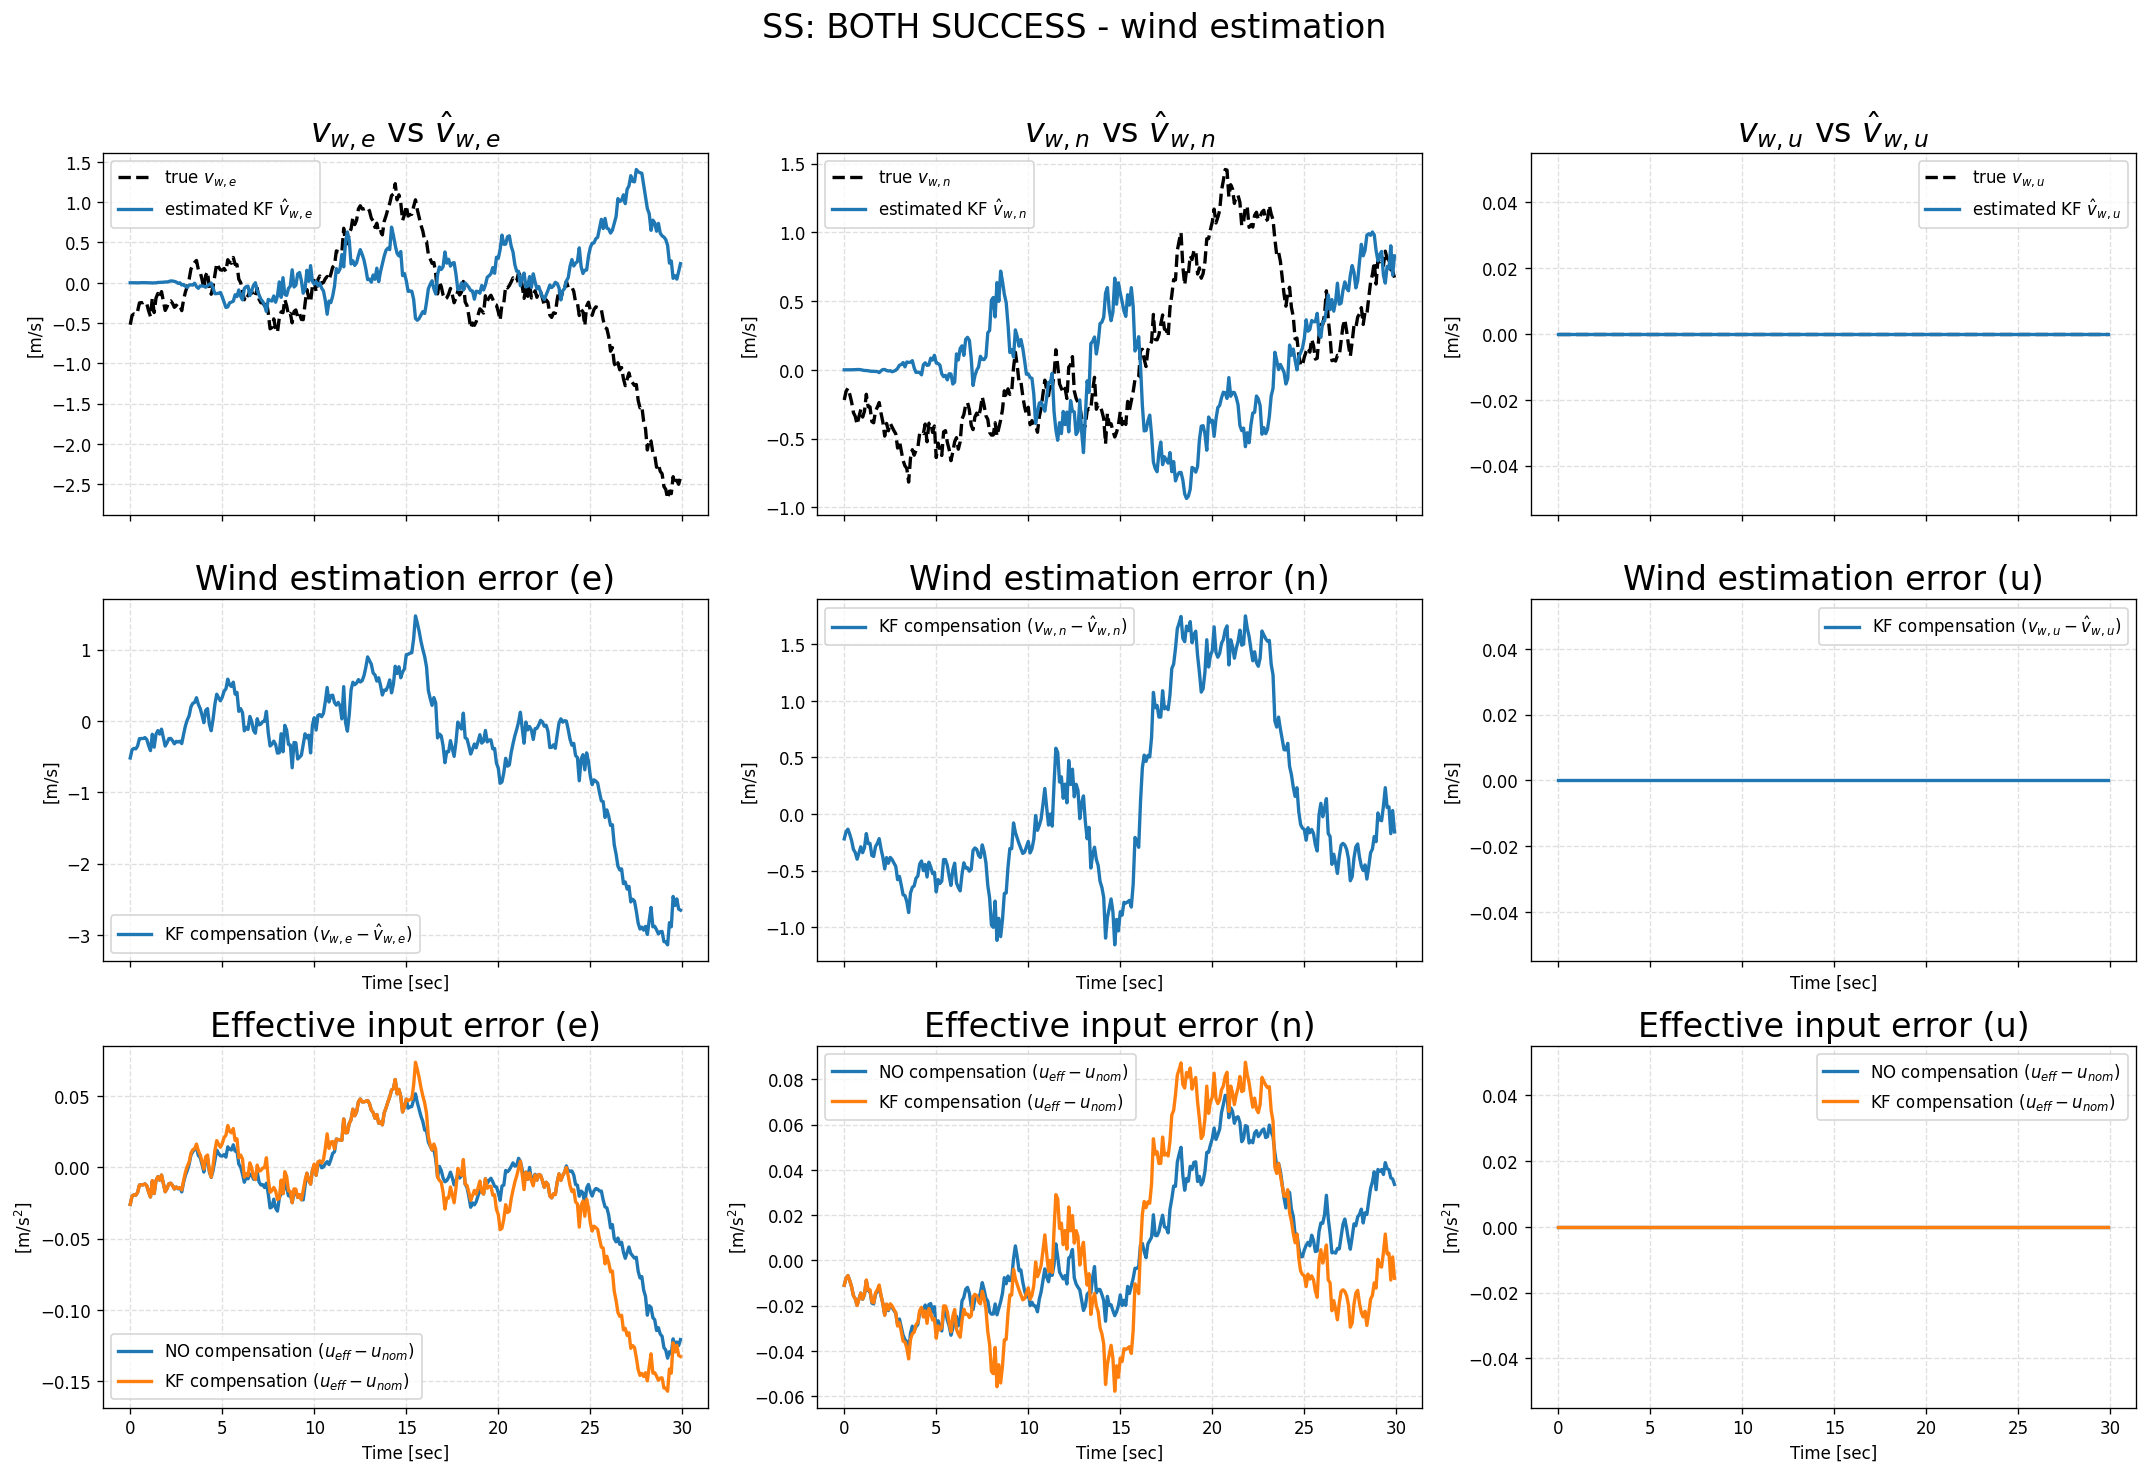

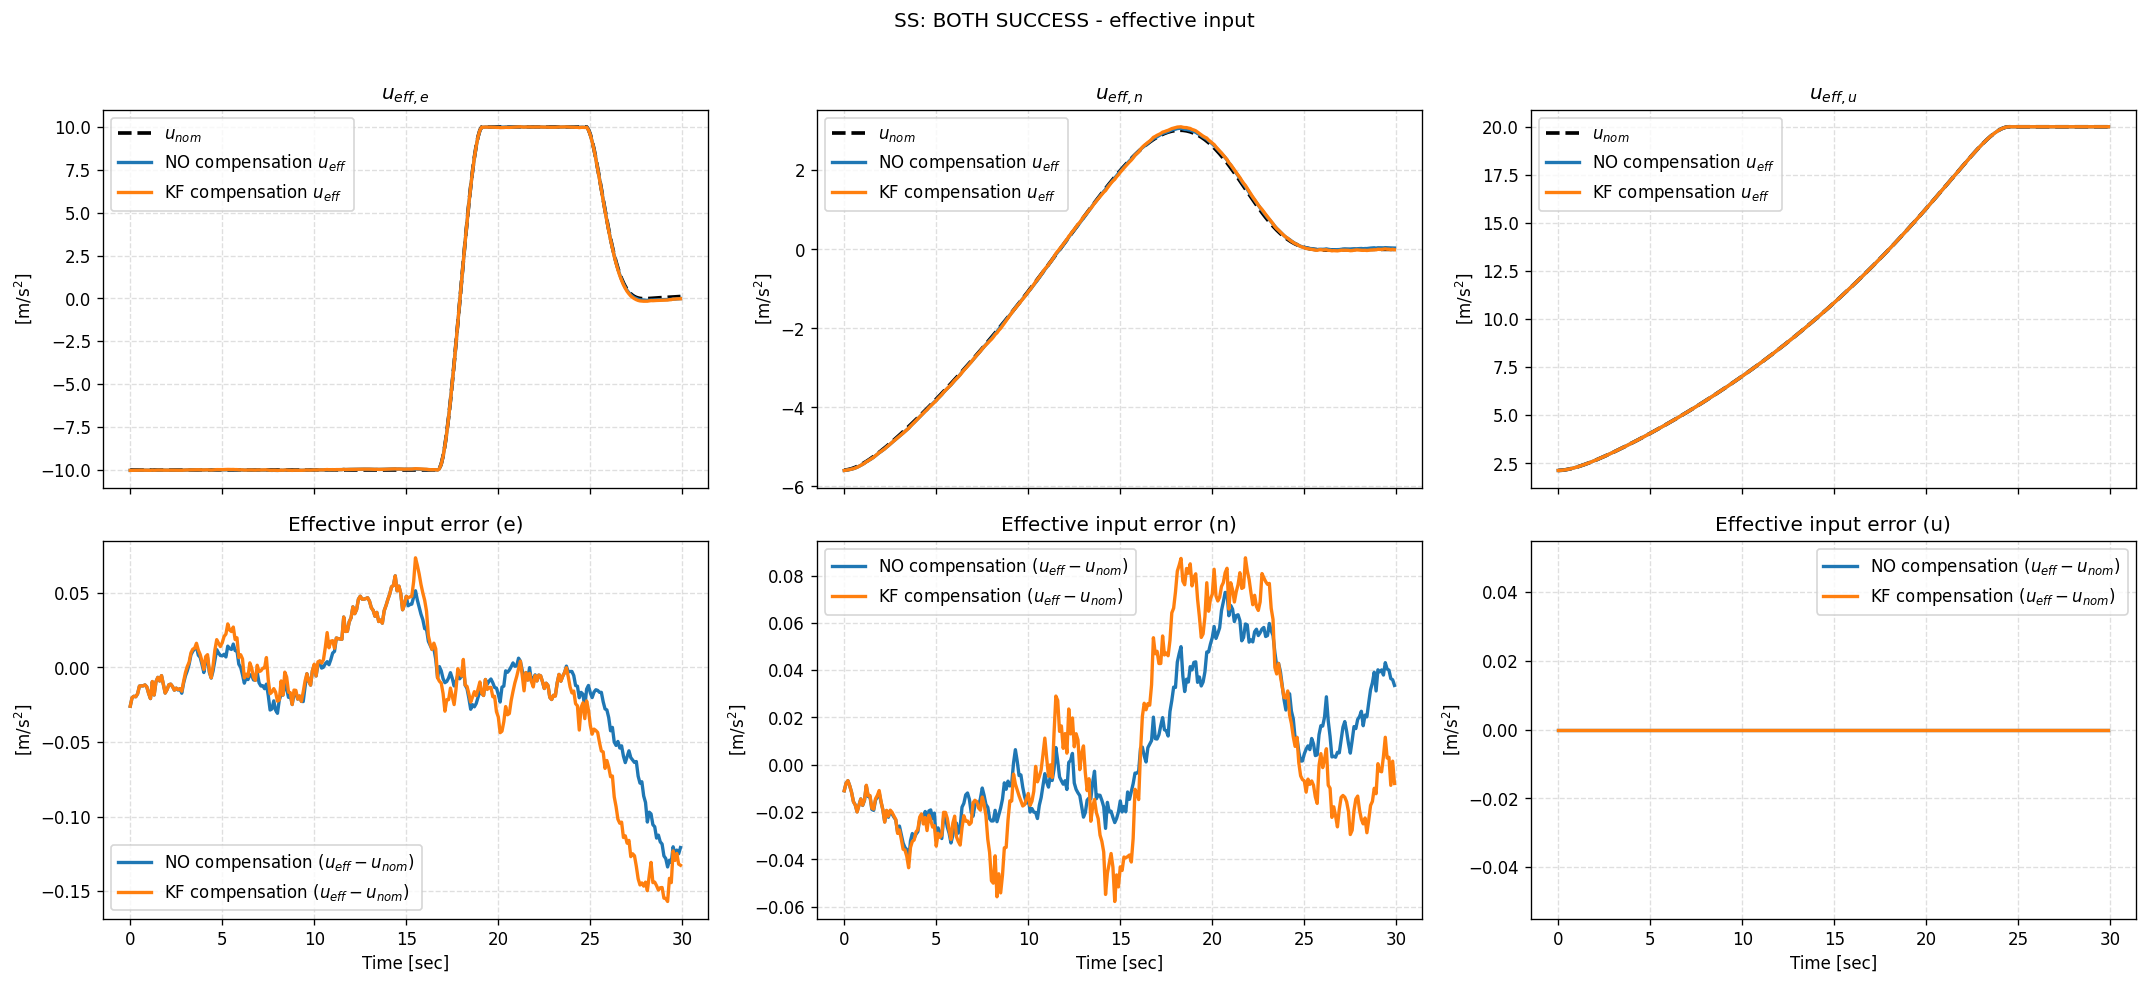


[FF: BOTH FAIL] idx=241
  No comp: success=False, err=40.913 m
  KF comp: success=False, err=30.032 m


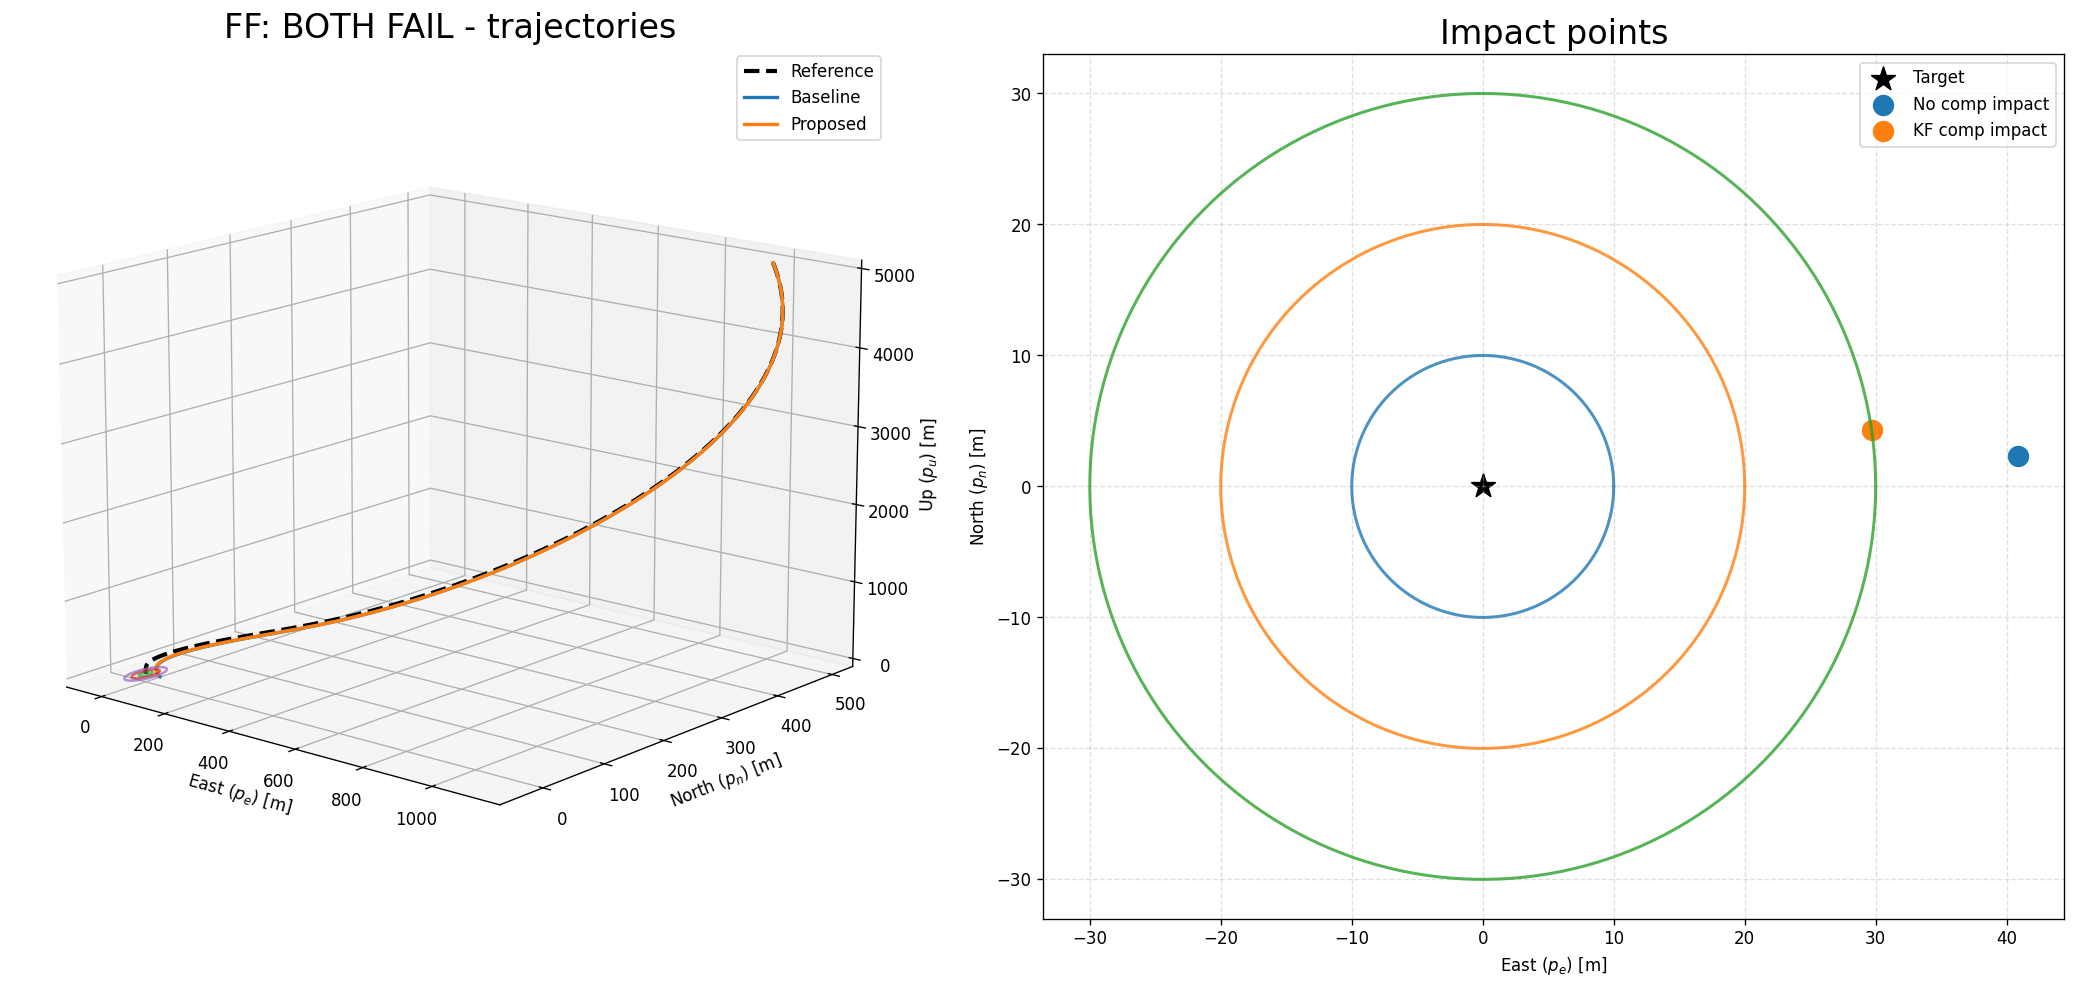

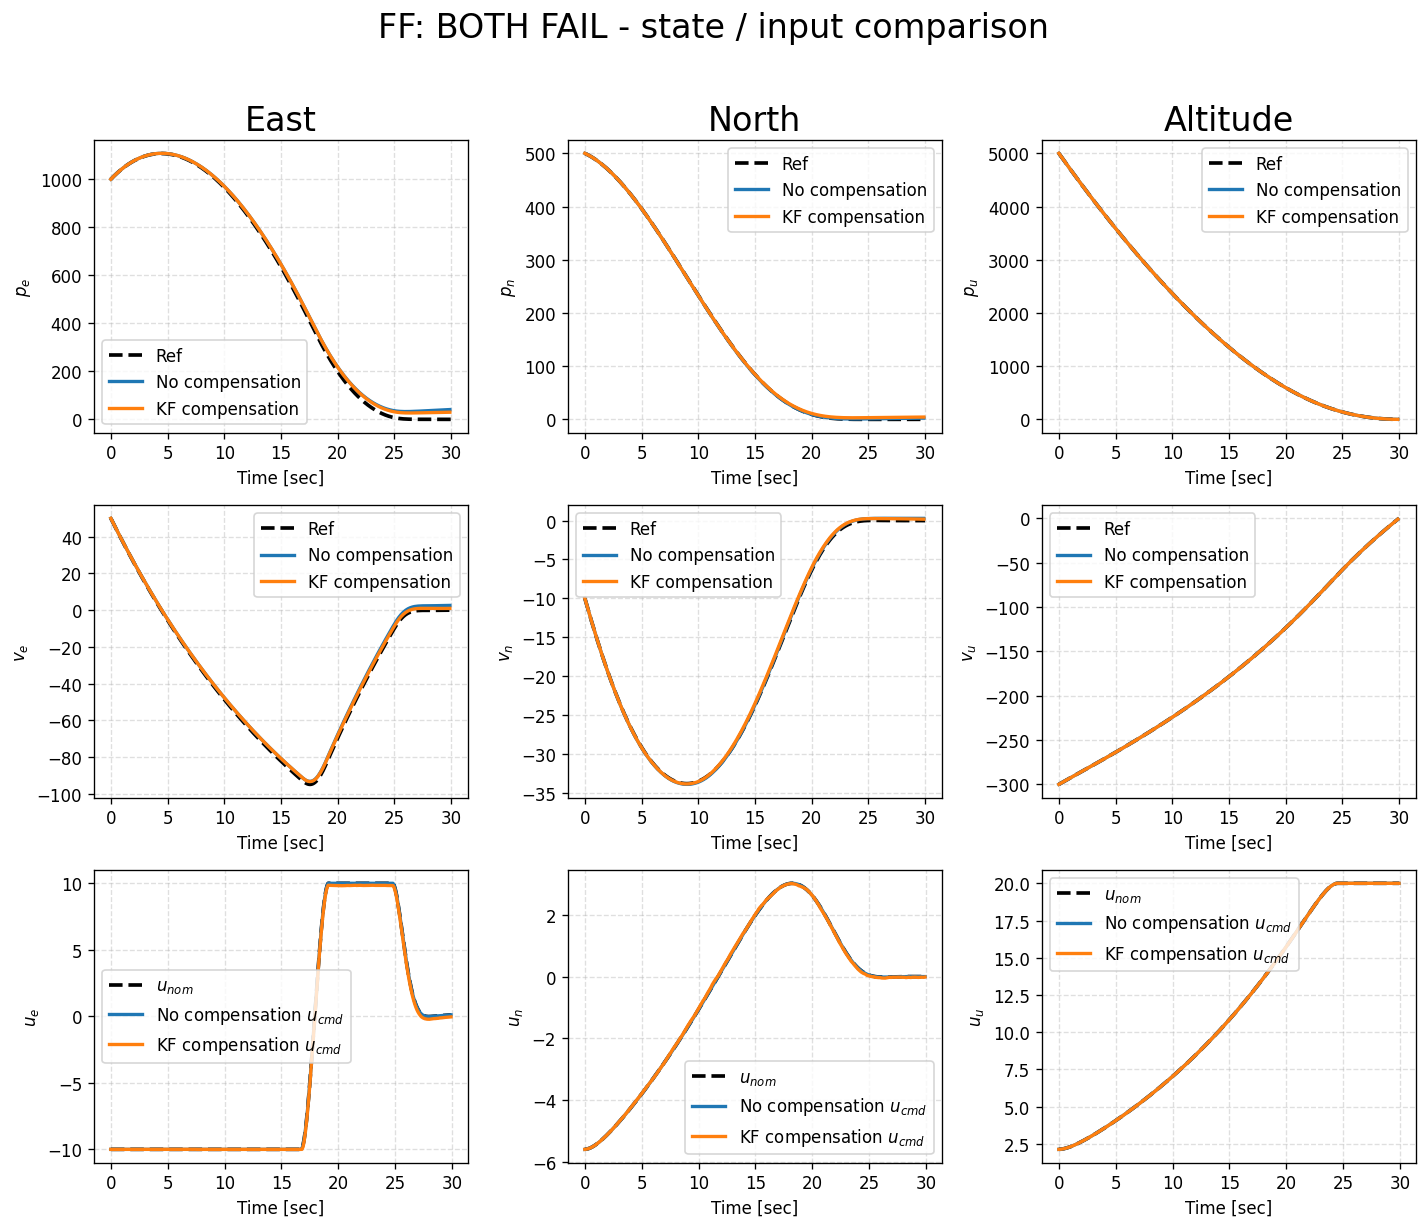

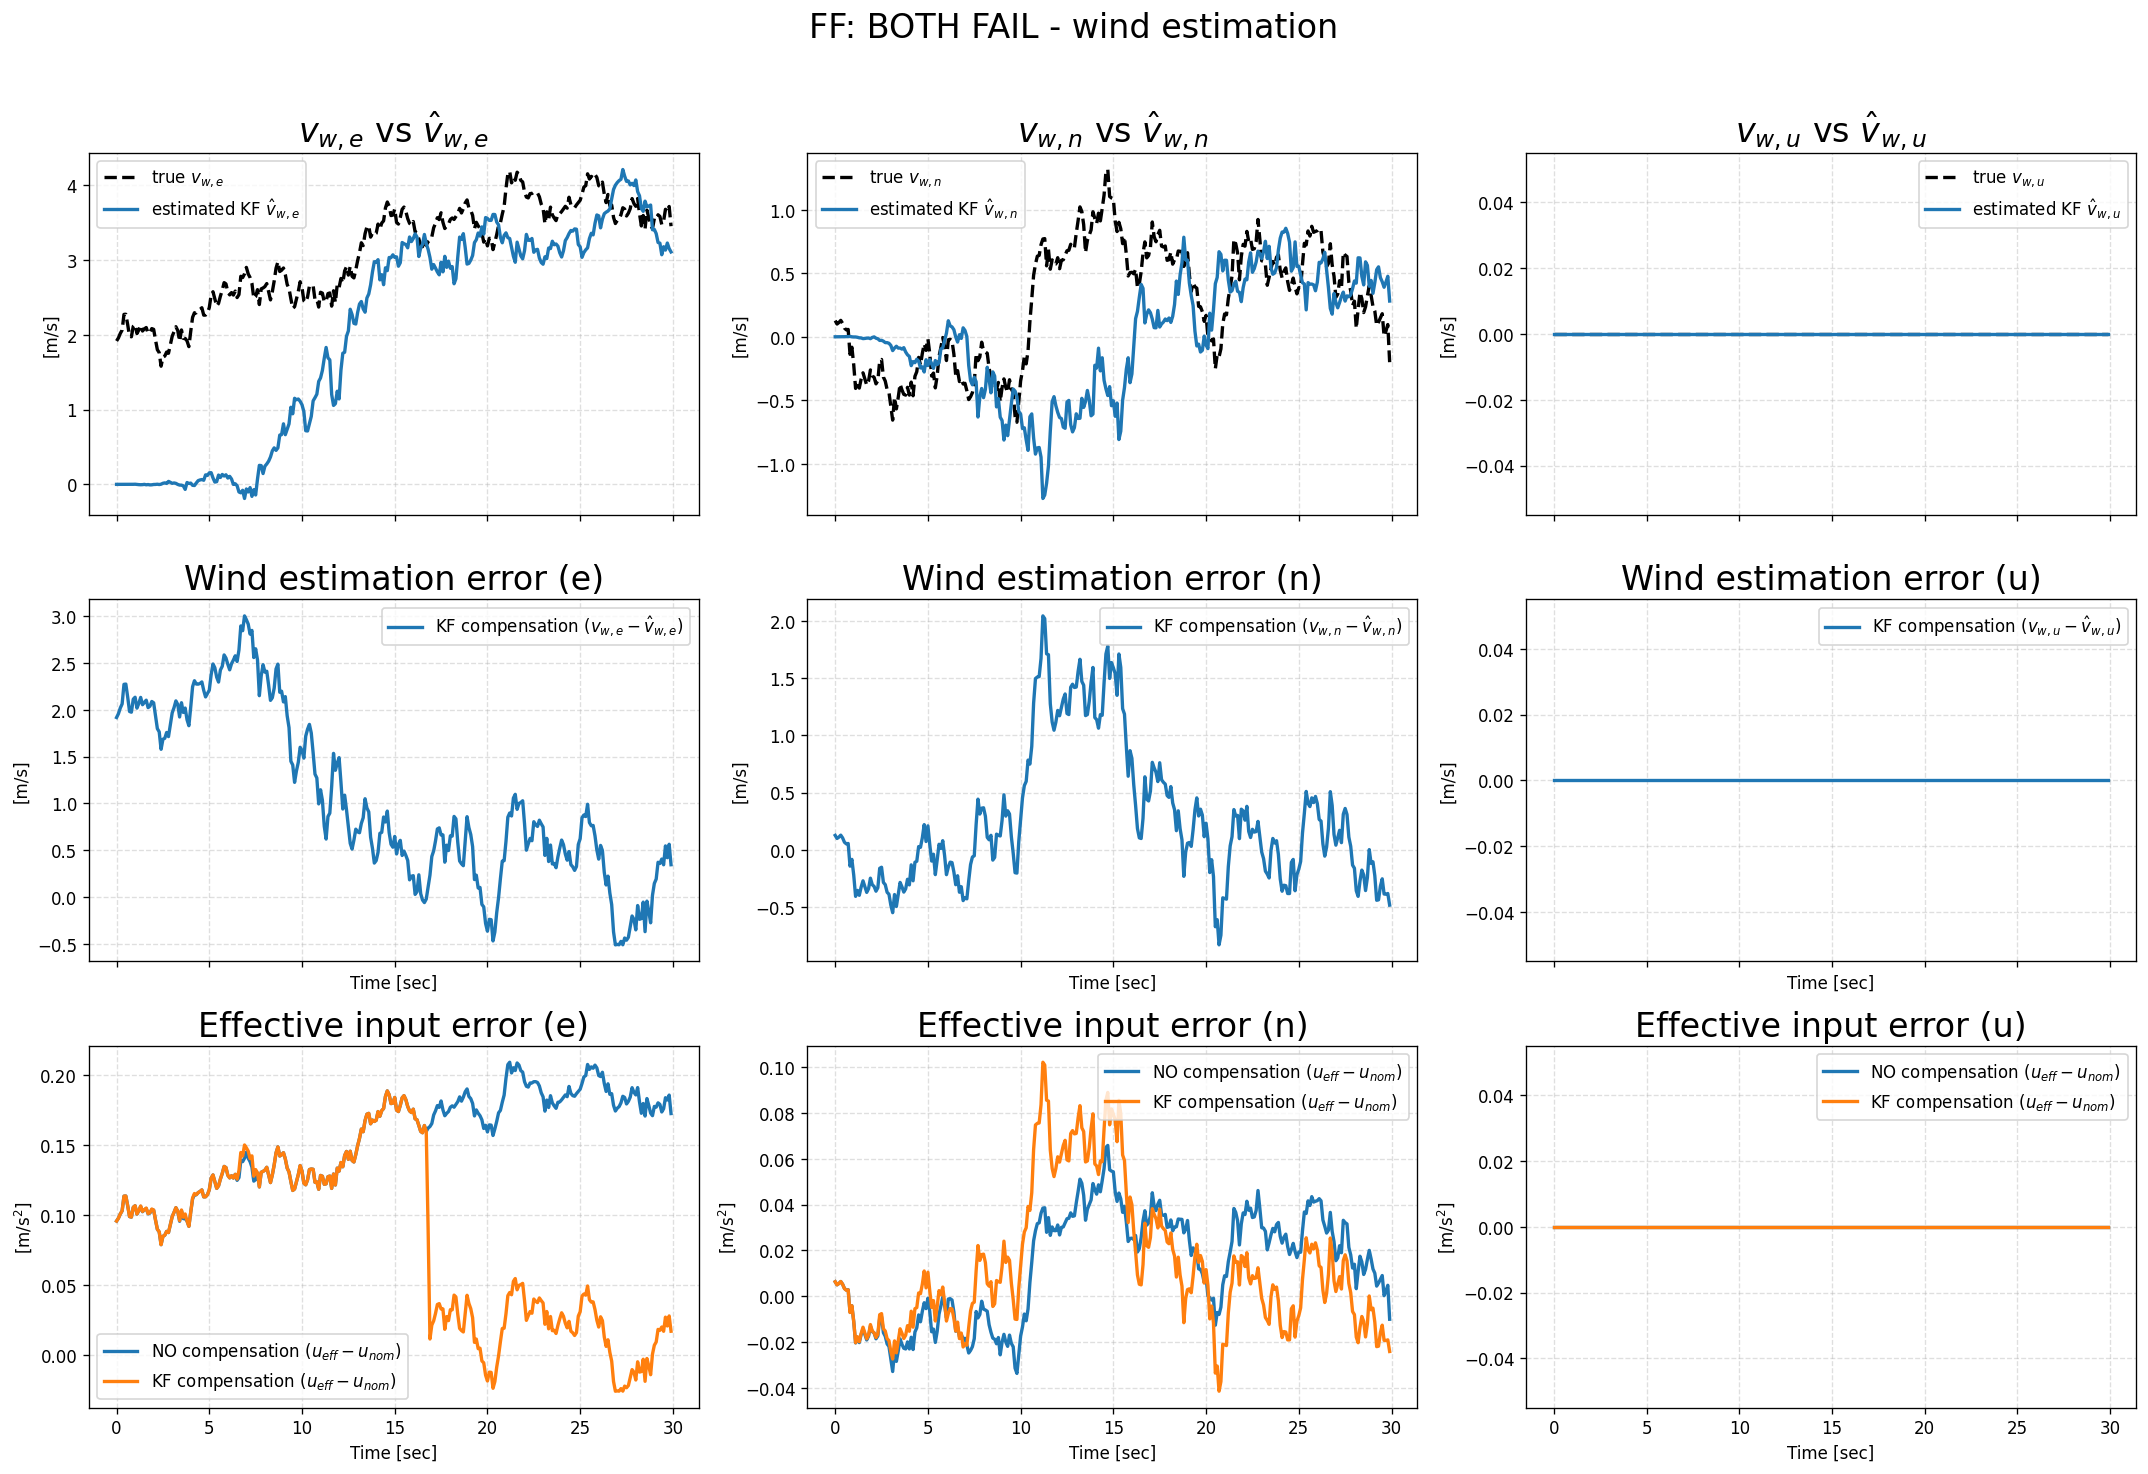

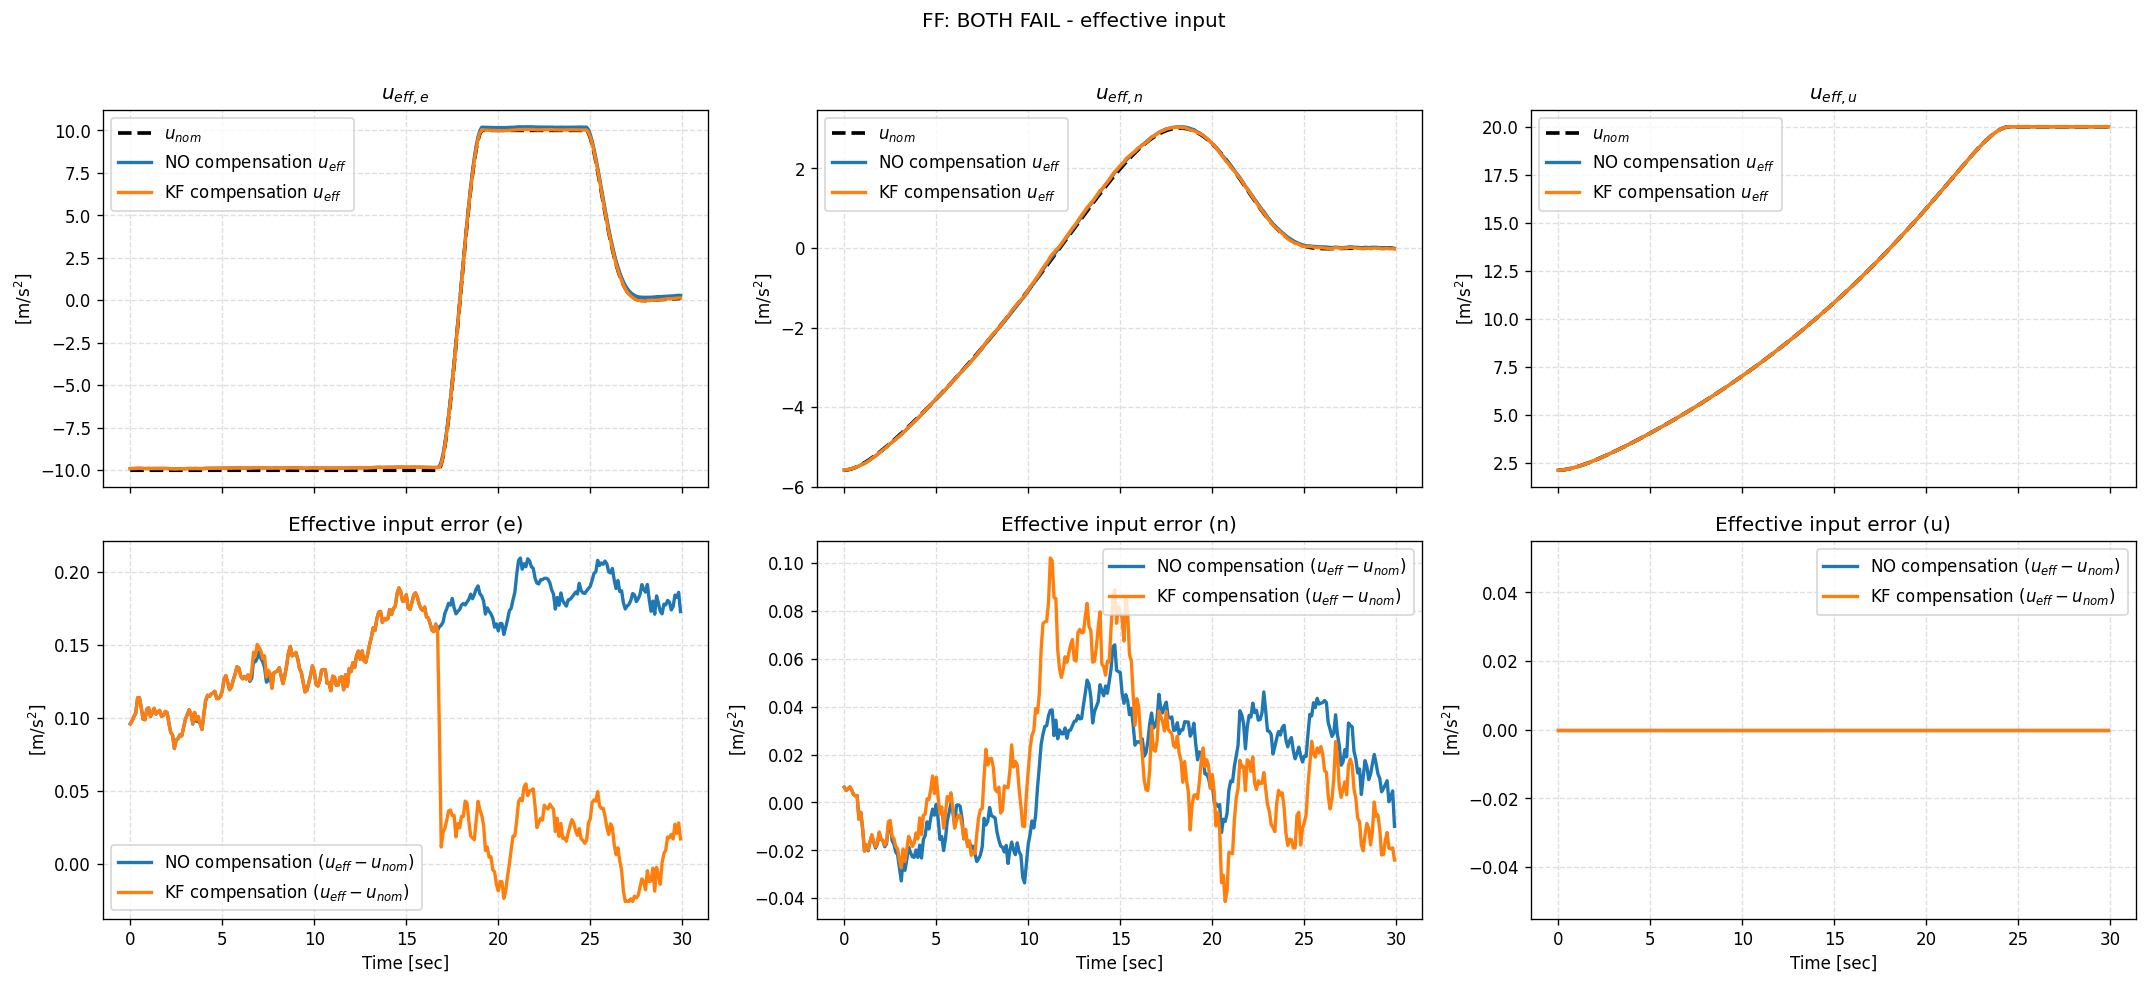

In [ ]:
# =========================
# [8] pair-wise comparison and representative trial plots
# =========================

def pick_representative(idxs, err_ref):
    if len(idxs) == 0:
        return None
    return int(idxs[np.nanargmin(err_ref[idxs])])

# Baseline vs Proposed
idx_SS = np.where(suc_base &  suc_comp)[0]
idx_FF = np.where(~suc_base & ~suc_comp)[0]
idx_FS = np.where(~suc_base &  suc_comp)[0]   # fail -> success
idx_SF = np.where(suc_base & ~suc_comp)[0]    # success -> fail

rep_FS = pick_representative(idx_FS, err_comp)
rep_SF = pick_representative(idx_SF, err_base)
rep_SS = pick_representative(idx_SS, err_comp)
rep_FF = pick_representative(idx_FF, err_comp)

print(f"SS (both success): {len(idx_SS)}")
print(f"FF (both fail)   : {len(idx_FF)}")
print(f"FS (Base fail, comp success): {len(idx_FS)}")
print(f"SF (Base success, comp fail): {len(idx_SF)}")
print("Representative indices (1-based):")
print("  FS:", None if rep_FS is None else rep_FS + 1)
print("  SF:", None if rep_SF is None else rep_SF + 1)
print("  SS:", None if rep_SS is None else rep_SS + 1)
print("  FF:", None if rep_FF is None else rep_FF + 1)


def plot_one_pair(i, title_tag=""):
    if i is None:
        print(f"[{title_tag}] No sample found.")
        return

    X_base   = trajs_base[i]
    Vw_true  = winds_base[i]          # same bank -> base/comp identical
    Xhat_base = xhats_base[i]
    U_base   = ucmds_base[i]

    X_comp   = trajs_comp[i]
    Xhat_comp = xhats_comp[i]
    U_comp   = ucmds_comp[i]

    ok_base = bool(suc_base[i])
    ok_comp = bool(suc_comp[i])
    e_base  = err_base[i]
    e_comp  = err_comp[i]

    print(f"\n[{title_tag}] idx={i+1}")
    print(f"  No comp: success={ok_base}, err={e_base:.3f} m")
    print(f"  KF comp: success={ok_comp}, err={e_comp:.3f} m")

    ts_x = ts
    ts_u = ts[:-1]
    theta = np.linspace(0, 2*np.pi, 400)
    radii = [10, 20, 30]

    # -------------------------------------------------
    # (A) 3D trajectories + impact points
    # -------------------------------------------------
    fig = plt.figure(figsize=(18, 8), dpi=120)

    ax1 = fig.add_subplot(1, 2, 1, projection="3d")
    ax1.view_init(elev=15, azim=-50, roll=0)

    ax1.plot(X_ref[0, :], X_ref[1, :], X_ref[2, :], "k--", linewidth=2.5, label="Reference")
    ax1.plot(X_base[0, :], X_base[1, :], X_base[2, :], linewidth=2.0, label="Baseline")
    ax1.plot(X_comp[0, :], X_comp[1, :], X_comp[2, :], linewidth=2.0, label="Proposed")

    for r in radii:
        ax1.plot(x_des[0] + r*np.cos(theta),
                 x_des[1] + r*np.sin(theta),
                 np.zeros_like(theta) + x_des[2], alpha=0.7)

    ax1.set_xlabel("East $(p_e)$ [m]")
    ax1.set_ylabel("North $(p_n)$ [m]")
    ax1.set_zlabel("Up $(p_u)$ [m]")
    ax1.set_title(f"{title_tag} - trajectories", fontsize=20)
    ax1.legend(loc="best")

    ax2 = fig.add_subplot(1, 2, 2)
    pe0, pn0 = impact_point_from_traj(X_base)
    pe1, pn1 = impact_point_from_traj(X_comp)

    ax2.scatter([x_des[0]], [x_des[1]], s=220, color="k", marker="*", label="Target")
    ax2.scatter([pe0], [pn0], s=140, label="No comp impact")
    ax2.scatter([pe1], [pn1], s=140, label="KF comp impact")

    for r in radii:
        ax2.plot(x_des[0] + r*np.cos(theta),
                 x_des[1] + r*np.sin(theta),
                 linewidth=1.8, alpha=0.8)

    ax2.set_aspect("equal", adjustable="box")
    ax2.set_xlabel("East $(p_e)$ [m]")
    ax2.set_ylabel("North $(p_n)$ [m]")
    ax2.set_title("Impact points", fontsize=20)
    ax2.grid(True, linestyle="--", alpha=0.4)
    ax2.legend(loc="best")

    plt.tight_layout()
    plt.show()

    # -------------------------------------------------
    # (B) State / input comparison
    # -------------------------------------------------
    pos_labels = [r"$p_e$", r"$p_n$", r"$p_u$"]
    vel_labels = [r"$v_e$", r"$v_n$", r"$v_u$"]
    u_labels   = [r"$u_e$", r"$u_n$", r"$u_u$"]
    titles = ["East", "North", "Altitude"]

    plt.figure(figsize=(12, 10), dpi=120)

    for k in range(3):
        ax = plt.subplot(3, 3, k+1)
        ax.plot(ts_x, X_ref[k, :], "k--", linewidth=2.2, label="Ref")
        ax.plot(ts_x, X_base[k, :], linewidth=2.0, label="No compensation")
        ax.plot(ts_x, X_comp[k, :], linewidth=2.0, label="KF compensation")
        ax.set_ylabel(pos_labels[k])
        ax.set_xlabel("Time [sec]")
        ax.set_title(titles[k], fontsize=20)
        ax.grid(True, linestyle="--", alpha=0.4)
        ax.legend()

    for k in range(3):
        ax = plt.subplot(3, 3, k+4)
        ax.plot(ts_x, X_ref[3+k, :], "k--", linewidth=2.2, label="Ref")
        ax.plot(ts_x, X_base[3+k, :], linewidth=2.0, label="No compensation")
        ax.plot(ts_x, X_comp[3+k, :], linewidth=2.0, label="KF compensation")
        ax.set_ylabel(vel_labels[k])
        ax.set_xlabel("Time [sec]")
        ax.grid(True, linestyle="--", alpha=0.4)
        ax.legend()

    for k in range(3):
        ax = plt.subplot(3, 3, k+7)
        ax.plot(ts_u, U_nom[k, :], "k--", linewidth=2.2, label=r"$u_{nom}$")
        ax.plot(ts_u, U_base[k, :], linewidth=2.0, label=r"No compensation $u_{cmd}$")
        ax.plot(ts_u, U_comp[k, :], linewidth=2.0, label=r"KF compensation $u_{cmd}$")
        ax.set_ylabel(u_labels[k])
        ax.set_xlabel("Time [sec]")
        ax.grid(True, linestyle="--", alpha=0.4)
        ax.legend()

    plt.suptitle(f"{title_tag} - state / input comparison", y=1.02, fontsize=20)
    plt.tight_layout()
    plt.show()

    # -------------------------------------------------
    # (C) True wind vs estimated wind
    # -------------------------------------------------
    Vwhat_base = Xhat_base[6:9, :-1]
    Vwhat_comp = Xhat_comp[6:9, :-1]

    fig, axes = plt.subplots(3, 3, figsize=(18, 12), dpi=120, sharex=True)

    # row 1: true vs estimate
    for j, lab in enumerate(["e", "n", "u"]):
        ax = axes[0, j]
        ax.plot(ts_u, Vw_true[j, :], "k--", linewidth=2.0, label=rf"true $v_{{w,{lab}}}$")
        #ax.plot(ts_u, Vwhat_base[j, :], linewidth=2.0, label=rf"No compensation $\hat v_{{w,{lab}}}$")
        ax.plot(ts_u, Vwhat_comp[j, :], linewidth=2.0, label=rf"estimated KF $\hat v_{{w,{lab}}}$")
        ax.set_title(rf"$v_{{w,{lab}}}$ vs $\hat v_{{w,{lab}}}$",fontsize=20)
        ax.set_ylabel("[m/s]")
        ax.grid(True, linestyle="--", alpha=0.4)
        ax.legend(loc="best")

    # row 2: estimation error
    for j, lab in enumerate(["e", "n", "u"]):
        ax = axes[1, j]
        ax.plot(ts_u, Vw_true[j, :] - Vwhat_comp[j, :], linewidth=2.0,
                label=rf"KF compensation $(v_{{w,{lab}}}-\hat v_{{w,{lab}}})$")
        ax.set_title(rf"Wind estimation error ({lab})",fontsize=20)
        ax.set_xlabel("Time [sec]")
        ax.set_ylabel("[m/s]")
        ax.grid(True, linestyle="--", alpha=0.4)
        ax.legend(loc="best")

    Ueff_base = U_base + gamma * Vw_true
    Ueff_comp = U_comp + gamma * Vw_true
    for j, lab in enumerate(["e", "n", "u"]):
        ax = axes[2, j]
        ax.plot(ts_u, Ueff_base[j, :] - U_nom[j, :], linewidth=2.0,
                label=r"NO compensation $(u_{eff}-u_{nom})$")
        ax.plot(ts_u, Ueff_comp[j, :] - U_nom[j, :], linewidth=2.0,
                label=r"KF compensation $(u_{eff}-u_{nom})$")
        ax.set_title(rf"Effective input error ({lab})",fontsize=20)
        ax.set_xlabel("Time [sec]")
        ax.set_ylabel(r"[m/s$^2$]")
        ax.grid(True, linestyle="--", alpha=0.4)
        ax.legend(loc="best")

    plt.suptitle(f"{title_tag} - wind estimation", y=1.02, fontsize=20)
    plt.tight_layout()
    plt.show()

    # -------------------------------------------------
    # (D) Effective input comparison
    # B u_cmd + G v_w = B (u_cmd + gamma v_w)
    # => effective input = u_cmd + gamma v_w
    # -------------------------------------------------
    Ueff_base = U_base + gamma * Vw_true
    Ueff_comp = U_comp + gamma * Vw_true

    fig, axes = plt.subplots(2, 3, figsize=(18, 8), dpi=120, sharex=True)

    for j, lab in enumerate(["e", "n", "u"]):
        ax = axes[0, j]
        ax.plot(ts_u, U_nom[j, :], "k--", linewidth=2.2, label=r"$u_{nom}$")
        ax.plot(ts_u, Ueff_base[j, :], linewidth=2.0, label=r"NO compensation $u_{eff}$")
        ax.plot(ts_u, Ueff_comp[j, :], linewidth=2.0, label=r"KF compensation $u_{eff}$")
        ax.set_title(rf"$u_{{eff,{lab}}}$")
        ax.set_ylabel(r"[m/s$^2$]")
        ax.grid(True, linestyle="--", alpha=0.4)
        ax.legend(loc="best")

    for j, lab in enumerate(["e", "n", "u"]):
        ax = axes[1, j]
        ax.plot(ts_u, Ueff_base[j, :] - U_nom[j, :], linewidth=2.0,
                label=r"NO compensation $(u_{eff}-u_{nom})$")
        ax.plot(ts_u, Ueff_comp[j, :] - U_nom[j, :], linewidth=2.0,
                label=r"KF compensation $(u_{eff}-u_{nom})$")
        ax.set_title(rf"Effective input error ({lab})")
        ax.set_xlabel("Time [sec]")
        ax.set_ylabel(r"[m/s$^2$]")
        ax.grid(True, linestyle="--", alpha=0.4)
        ax.legend(loc="best")

    plt.suptitle(f"{title_tag} - effective input", y=1.02)
    plt.tight_layout()
    plt.show()


plot_one_pair(rep_FS, title_tag="NO comp FAIL, KF comp SUCCESS")
plot_one_pair(rep_SF, title_tag="SF: NO comp SUCCESS, KF comp FAIL")
plot_one_pair(rep_SS, title_tag="SS: BOTH SUCCESS")
plot_one_pair(rep_FF, title_tag="FF: BOTH FAIL")

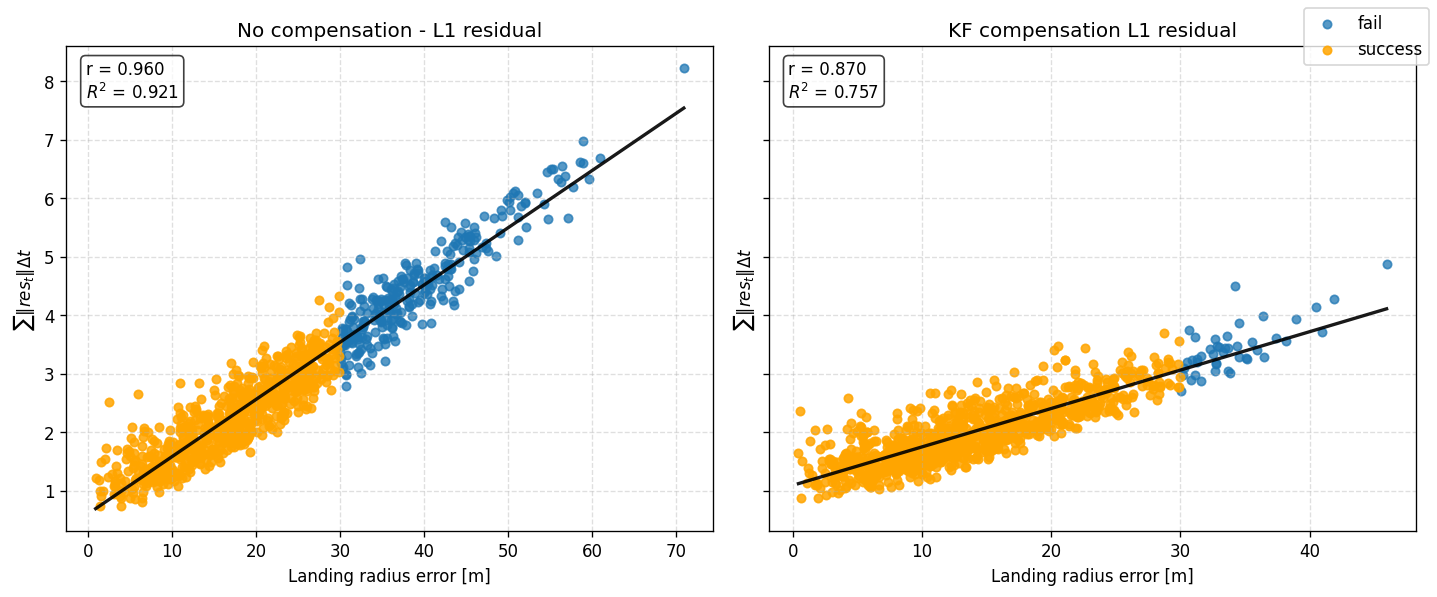

In [ ]:
# =========================
# [9] optional residual analysis
# effective input: u_eff = u_cmd + gamma * v_w
# residual wrt nominal: r_t = u_eff - u_nom
# =========================

def pearson_r(x, y):
    x = np.asarray(x)
    y = np.asarray(y)
    x = x - np.mean(x)
    y = y - np.mean(y)
    return float((x @ y) / (np.linalg.norm(x) * np.linalg.norm(y) + 1e-12))


def effective_input_metrics(X, Vw, Ucmd, U_nom, gamma, ts):
    k = impact_index_from_traj(X)
    if k is None or k <= 0:
        return np.nan, np.nan, np.nan

    dt = ts[1] - ts[0]
    t_end = min(k, U_nom.shape[1], Vw.shape[1], Ucmd.shape[1])

    Ueff = Ucmd[:, :t_end] + gamma * Vw[:, :t_end]
    r = Ueff - U_nom[:, :t_end]

    mask = np.isfinite(r).all(axis=0)
    r = r[:, mask]

    if r.shape[1] == 0:
        return np.nan, np.nan, np.nan

    rmag = np.linalg.norm(r, axis=0)

    S_L1 = np.sum(rmag) * dt
    S_L2 = np.sum(rmag**2) * dt
    Rmax = np.max(rmag)
    return S_L1, S_L2, Rmax


def plot_residual_scatter_L1_1x2(
    trajs_base, winds_base, ucmds_base,
    trajs_comp, winds_comp, ucmds_comp,
    U_nom, gamma, x_des, ts
):
    # success / radius error
    rad_base, _, suc_base = compute_case_metrics(trajs_base, x_des, R_SUCCESS, V_SUCCESS)
    rad_comp, _, suc_comp = compute_case_metrics(trajs_comp, x_des, R_SUCCESS, V_SUCCESS)

    # L1 metric only
    S_L1_base = np.full(len(trajs_base), np.nan)
    S_L1_comp = np.full(len(trajs_comp), np.nan)

    for i in range(len(trajs_base)):
        a, _, _ = effective_input_metrics(trajs_base[i], winds_base[i], ucmds_base[i], U_nom, gamma, ts)
        S_L1_base[i] = a

    for i in range(len(trajs_comp)):
        a, _, _ = effective_input_metrics(trajs_comp[i], winds_comp[i], ucmds_comp[i], U_nom, gamma, ts)
        S_L1_comp[i] = a

    def one_panel(ax, x, y, suc, panel_title):
        mask = np.isfinite(x) & np.isfinite(y)
        xs, ys = x[mask], y[mask]
        ss = suc[mask]

        ax.scatter(xs[~ss], ys[~ss], s=25, alpha=0.75, label="fail")
        ax.scatter(xs[ ss], ys[ ss], s=25, alpha=0.85, color="orange", label="success")

        if len(xs) >= 2:
            a, b = np.polyfit(xs, ys, 1)
            xline = np.linspace(xs.min(), xs.max(), 200)
            ax.plot(xline, a*xline + b, color="k", linewidth=2.0, alpha=0.9)

            r = pearson_r(xs, ys)
            yhat = a * xs + b
            sse = np.sum((ys - yhat)**2)
            sst = np.sum((ys - ys.mean())**2) + 1e-12
            R2 = 1.0 - sse / sst

            ax.text(
                0.03, 0.97,
                f"r = {r:.3f}\n$R^2$ = {R2:.3f}",
                transform=ax.transAxes,
                va="top", ha="left",
                bbox=dict(boxstyle="round", facecolor="white", alpha=0.75)
            )

        ax.set_title(panel_title)
        ax.set_xlabel("Landing radius error [m]")
        ax.set_ylabel(r"$\sum \|res_t\| \Delta t$")
        ax.grid(True, linestyle="--", alpha=0.4)

    fig, axes = plt.subplots(1, 2, figsize=(12, 5), dpi=120, sharey=True)

    one_panel(
        axes[0],
        rad_base, S_L1_base, suc_base,
        "No compensation - L1 residual"
    )

    one_panel(
        axes[1],
        rad_comp, S_L1_comp, suc_comp,
        "KF compensation L1 residual"
    )

    handles, labels = axes[0].get_legend_handles_labels()
    fig.legend(handles, labels, frameon=True)

    plt.tight_layout()
    plt.show()


# 실행
plot_residual_scatter_L1_1x2(
    trajs_base, winds_base, ucmds_base,
    trajs_comp, winds_comp, ucmds_comp,
    U_nom, gamma, x_des, ts
)

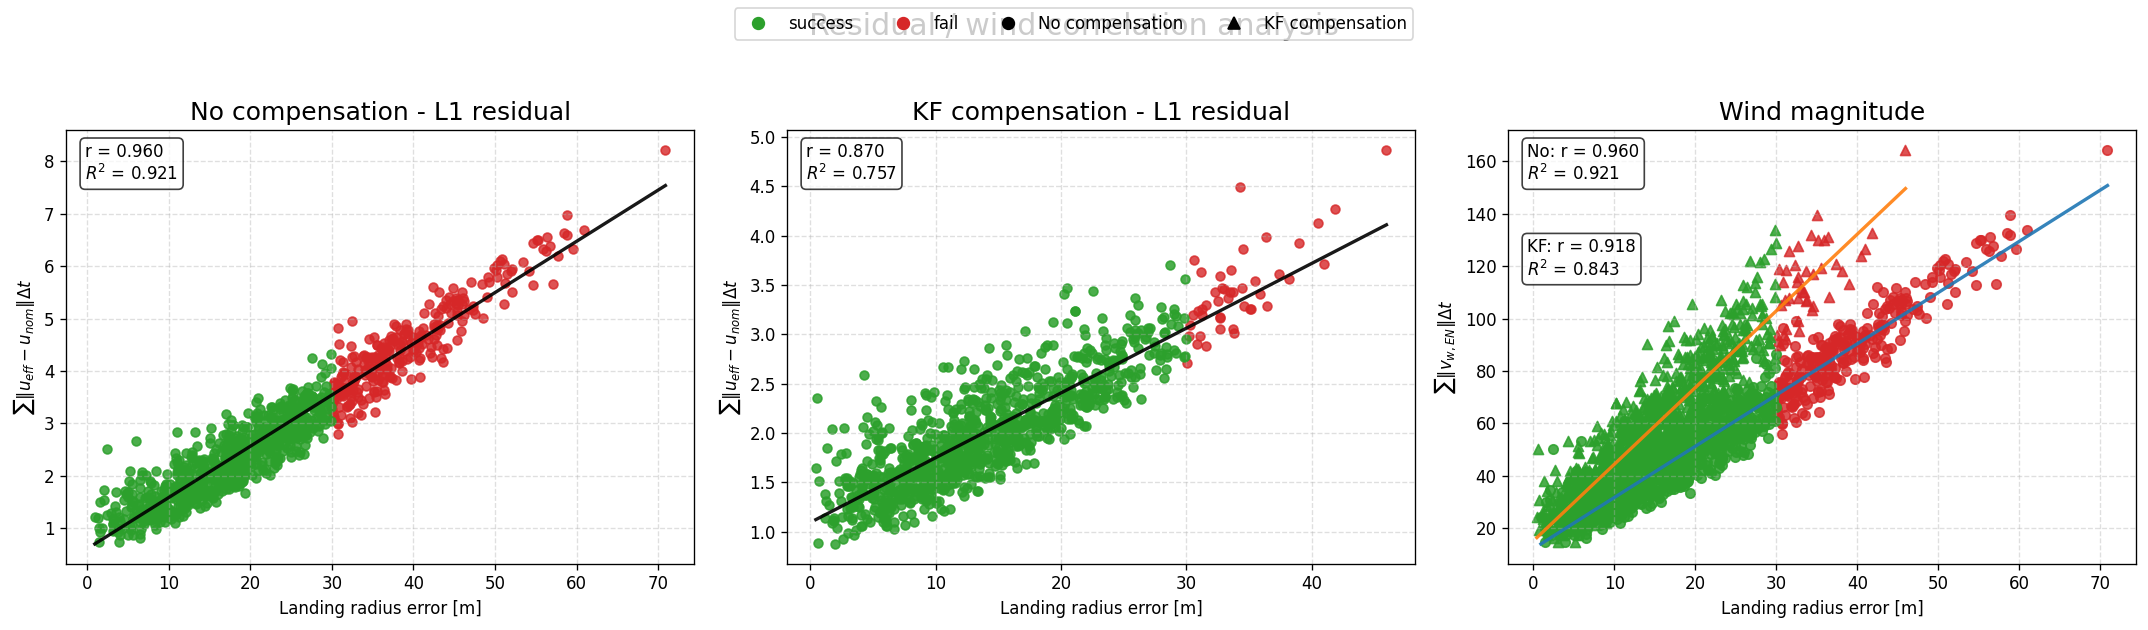

In [ ]:
# =========================
# [9] residual / wind correlation analysis (1x3)
# x-axis fixed = landing radius error
# color = success/fail
# marker = method (No: o, KF: ^)
# =========================

import numpy as np
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D

def pearson_r(x, y):
    x = np.asarray(x)
    y = np.asarray(y)
    x = x - np.mean(x)
    y = y - np.mean(y)
    return float((x @ y) / (np.linalg.norm(x) * np.linalg.norm(y) + 1e-12))


def effective_input_metrics(X, Vw, Ucmd, U_nom, gamma, ts):
    k = impact_index_from_traj(X)
    if k is None or k <= 0:
        return np.nan, np.nan, np.nan

    dt = ts[1] - ts[0]
    t_end = min(k, U_nom.shape[1], Vw.shape[1], Ucmd.shape[1])

    Ueff = Ucmd[:, :t_end] + gamma * Vw[:, :t_end]
    r = Ueff - U_nom[:, :t_end]

    mask = np.isfinite(r).all(axis=0)
    r = r[:, mask]

    if r.shape[1] == 0:
        return np.nan, np.nan, np.nan

    rmag = np.linalg.norm(r, axis=0)

    S_L1 = np.sum(rmag) * dt
    S_L2 = np.sum(rmag**2) * dt
    Rmax = np.max(rmag)
    return S_L1, S_L2, Rmax


def wind_magnitude_metrics(X, Vw, ts):
    """
    horizontal wind magnitude metric up to impact:
        W_L1 = sum ||v_w,EN|| dt
        W_L2 = sum ||v_w,EN||^2 dt
        Wmax = max ||v_w,EN||
    """
    k = impact_index_from_traj(X)
    if k is None or k <= 0:
        return np.nan, np.nan, np.nan

    dt = ts[1] - ts[0]
    t_end = min(k, Vw.shape[1])

    W = Vw[0:2, :t_end]   # EN only
    mask = np.isfinite(W).all(axis=0)
    W = W[:, mask]

    if W.shape[1] == 0:
        return np.nan, np.nan, np.nan

    wmag = np.linalg.norm(W, axis=0)

    W_L1 = np.sum(wmag) * dt
    W_L2 = np.sum(wmag**2) * dt
    Wmax = np.max(wmag)
    return W_L1, W_L2, Wmax


def _fit_and_annotate(ax, x, y, color="k", text_xy=(0.03, 0.97), label_prefix=""):
    mask = np.isfinite(x) & np.isfinite(y)
    xs, ys = np.asarray(x)[mask], np.asarray(y)[mask]

    if len(xs) < 2 or np.std(xs) < 1e-12:
        return

    a, b = np.polyfit(xs, ys, 1)
    xline = np.linspace(xs.min(), xs.max(), 200)
    ax.plot(xline, a * xline + b, color=color, linewidth=2.0, alpha=0.9)

    r = pearson_r(xs, ys)
    yhat = a * xs + b
    sse = np.sum((ys - yhat)**2)
    sst = np.sum((ys - ys.mean())**2) + 1e-12
    R2 = 1.0 - sse / sst

    txt = f"{label_prefix}r = {r:.3f}\n$R^2$ = {R2:.3f}"
    ax.text(
        text_xy[0], text_xy[1],
        txt,
        transform=ax.transAxes,
        va="top", ha="left",
        bbox=dict(boxstyle="round", facecolor="white", alpha=0.75)
    )


def _plot_single_case_panel(ax, x, y, suc, title, ylabel):
    mask = np.isfinite(x) & np.isfinite(y)
    xs, ys = np.asarray(x)[mask], np.asarray(y)[mask]
    ss = np.asarray(suc)[mask]

    # fail / success color
    ax.scatter(xs[~ss], ys[~ss], s=28, alpha=0.80, color="tab:red")
    ax.scatter(xs[ ss], ys[ ss], s=28, alpha=0.85, color="tab:green")

    _fit_and_annotate(ax, xs, ys, color="k", text_xy=(0.03, 0.97))

    ax.set_title(title, fontsize=15)
    ax.set_xlabel("Landing radius error [m]")
    ax.set_ylabel(ylabel)
    ax.grid(True, linestyle="--", alpha=0.4)


def _plot_wind_panel(ax,
                     x_no, y_no, suc_no,
                     x_kf, y_kf, suc_kf,
                     ylabel):
    # No compensation: circle marker
    mask_no = np.isfinite(x_no) & np.isfinite(y_no)
    xn, yn = np.asarray(x_no)[mask_no], np.asarray(y_no)[mask_no]
    sn = np.asarray(suc_no)[mask_no]

    ax.scatter(xn[~sn], yn[~sn], s=32, alpha=0.80, color="tab:red", marker="o")
    ax.scatter(xn[ sn], yn[ sn], s=32, alpha=0.85, color="tab:green", marker="o")

    # KF compensation: triangle marker
    mask_kf = np.isfinite(x_kf) & np.isfinite(y_kf)
    xk, yk = np.asarray(x_kf)[mask_kf], np.asarray(y_kf)[mask_kf]
    sk = np.asarray(suc_kf)[mask_kf]

    ax.scatter(xk[~sk], yk[~sk], s=36, alpha=0.80, color="tab:red", marker="^")
    ax.scatter(xk[ sk], yk[ sk], s=36, alpha=0.85, color="tab:green", marker="^")

    # separate fit lines
    _fit_and_annotate(ax, xn, yn, color="tab:blue",  text_xy=(0.03, 0.97), label_prefix="No: ")
    _fit_and_annotate(ax, xk, yk, color="tab:orange", text_xy=(0.03, 0.75), label_prefix="KF: ")

    ax.set_title("Wind magnitude", fontsize=15)
    ax.set_xlabel("Landing radius error [m]")
    ax.set_ylabel(ylabel)
    ax.grid(True, linestyle="--", alpha=0.4)


def plot_residual_scatter_L1_1x3(
    trajs_base, winds_base, ucmds_base,
    trajs_comp, winds_comp, ucmds_comp,
    U_nom, gamma, x_des, ts,
    wind_bank=None
):
    # -------------------------
    # success / radius error
    # -------------------------
    rad_base, _, suc_base = compute_case_metrics(trajs_base, x_des, R_SUCCESS, V_SUCCESS)
    rad_comp, _, suc_comp = compute_case_metrics(trajs_comp, x_des, R_SUCCESS, V_SUCCESS)

    # -------------------------
    # metric arrays
    # -------------------------
    S_L1_base = np.full(len(trajs_base), np.nan)
    S_L1_comp = np.full(len(trajs_comp), np.nan)

    W_L1_base = np.full(len(trajs_base), np.nan)
    W_L1_comp = np.full(len(trajs_comp), np.nan)

    for i in range(len(trajs_base)):
        # residual metric
        a, _, _ = effective_input_metrics(
            trajs_base[i], winds_base[i], ucmds_base[i], U_nom, gamma, ts
        )
        S_L1_base[i] = a

        a, _, _ = effective_input_metrics(
            trajs_comp[i], winds_comp[i], ucmds_comp[i], U_nom, gamma, ts
        )
        S_L1_comp[i] = a

        # wind metric
        # wind_bank가 있으면 원래 생성한 같은 바람 시퀀스 사용
        if wind_bank is not None:
            a, _, _ = wind_magnitude_metrics(trajs_base[i], wind_bank[i], ts)
            W_L1_base[i] = a

            a, _, _ = wind_magnitude_metrics(trajs_comp[i], wind_bank[i], ts)
            W_L1_comp[i] = a
        else:
            a, _, _ = wind_magnitude_metrics(trajs_base[i], winds_base[i], ts)
            W_L1_base[i] = a

            a, _, _ = wind_magnitude_metrics(trajs_comp[i], winds_comp[i], ts)
            W_L1_comp[i] = a

    # -------------------------
    # plot
    # -------------------------
    fig, axes = plt.subplots(1, 3, figsize=(18, 5), dpi=120)

    _plot_single_case_panel(
        axes[0],
        rad_base, S_L1_base, suc_base,
        "No compensation - L1 residual",
        r"$\sum \|u_{eff}-u_{nom}\| \Delta t$"
    )

    _plot_single_case_panel(
        axes[1],
        rad_comp, S_L1_comp, suc_comp,
        "KF compensation - L1 residual",
        r"$\sum \|u_{eff}-u_{nom}\| \Delta t$"
    )

    _plot_wind_panel(
        axes[2],
        rad_base, W_L1_base, suc_base,
        rad_comp, W_L1_comp, suc_comp,
        r"$\sum \|v_{w,EN}\| \Delta t$"
    )

    # global legend
    legend_handles = [
        Line2D([0], [0], marker='o', color='w', markerfacecolor='tab:green',
               markeredgecolor='tab:green', markersize=7, linestyle='None', label='success'),
        Line2D([0], [0], marker='o', color='w', markerfacecolor='tab:red',
               markeredgecolor='tab:red', markersize=7, linestyle='None', label='fail'),
        Line2D([0], [0], marker='o', color='k', markersize=7, linestyle='None',
               label='No compensation'),
        Line2D([0], [0], marker='^', color='k', markersize=7, linestyle='None',
               label='KF compensation'),
    ]
    fig.legend(handles=legend_handles, loc="upper center", ncol=4, frameon=True)

    plt.suptitle("Residual / wind correlation analysis", y=1.04, fontsize=18)
    plt.tight_layout()
    plt.show()


# =========================
# 실행
# wind_bank 있으면 같이 넣는 게 제일 깔끔함
# =========================
plot_residual_scatter_L1_1x3(
    trajs_base, winds_base, ucmds_base,
    trajs_comp, winds_comp, ucmds_comp,
    U_nom, gamma, x_des, ts,
    wind_bank=wind_bank
)